In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### Loading the data

In [2]:
import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/IBPS/bail_with_crime_classification.csv")

In [3]:
df.head()

,CNR,bail_type,is_withdrawal,age,health_issues,past_criminal_record,statutes,outcome,date_of_arrest,date_of_judgement,case_details_length,case_detals,Crime
0,KLHC010003852010,Anticipatory-Bail,No,40,NaN,No,"['Section 341 IPC', 'Section 376 IPC', 'Sectio...",Not Granted,Unknown,26-07-2010,810,The accused are charged with offences related ...,['Sexual assault']
1,KLHC010008822010,Regular-Bail,No,30,NaN,No,"['Section 143 IPC', 'Section 147 IPC', 'Sectio...",Not Granted,05-01-2010,08-03-2010,730,The accused are charged with offences related ...,['Kidnapping and abduction']
2,HCBM010413142013,Anticipatory-Bail,No,Unknown,NaN,No,"['Section 465 IPC', 'Section 467 IPC', 'Sectio...",Not Granted,Unknown,23-10-2013,579,The applicant apprehends arrest in furtherance...,['Fraud and forgery']
3,HCBM010130592019,Anticipatory-Bail,No,Unknown,NaN,Yes,"['Section 415 IPC', 'Section 420 IPC', 'Sectio...",Granted,Unknown,Unknown,517,The applicants are apprehending arrest in a ca...,['White-collar crimes']
4,HCBM010049052020,Anticipatory-Bail,No,Unknown,NaN,No,"['Section 467 IPC', 'Section 468 IPC', 'Sectio...",Not Granted,Unknown,26-02-2020,416,"The applicant, Eknath Kondiba Bhujbal, is impl...",['Fraud and forgery']


In [4]:
import pandas as pd

data = {'High Court ': ['Chattisgrah','Bombay','Jharkhand','Kerala','Allahabad'],
        'Cases': [4689, 49606, 75000, 54997, 24000]}

df_high_courts = pd.DataFrame(data)
display(df_high_courts)

,High Court,Cases
0,Chattisgrah,4689
1,Bombay,49606
2,Jharkhand,75000
3,Kerala,54997
4,Allahabad,24000


/tmp/ipython-input-5-1366302256.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='High Court ', y='Cases', data=df_high_courts, palette=colors)


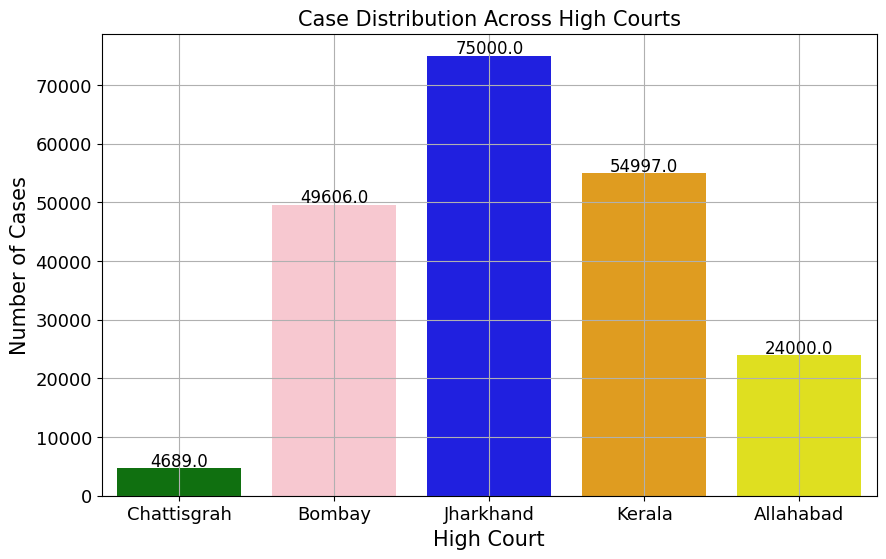

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

colors = ['green', 'pink', 'blue', 'orange', 'yellow']

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='High Court ', y='Cases', data=df_high_courts, palette=colors)
plt.title('Case Distribution Across High Courts',fontsize=15)
plt.xlabel('High Court',fontsize=15)
plt.ylabel('Number of Cases',fontsize=15)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# Add count labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5),
                textcoords='offset points', fontsize=12)


plt.grid(True)
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150430 entries, 0 to 150429
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   CNR                   150430 non-null  object
 1   bail_type             150430 non-null  object
 2   is_withdrawal         150430 non-null  object
 3   age                   150430 non-null  object
 4   health_issues         3686 non-null    object
 5   past_criminal_record  150430 non-null  object
 6   statutes              150430 non-null  object
 7   outcome               150430 non-null  object
 8   date_of_arrest        150311 non-null  object
 9   date_of_judgement     150286 non-null  object
 10  case_details_length   150430 non-null  int64 
 11  case_detals           150430 non-null  object
 12  Crime                 150430 non-null  object
dtypes: int64(1), object(12)
memory usage: 14.9+ MB


### Cleaning small things

In [6]:
import numpy as np

# Convert 'Unknown' to NaN
df['age'] = df['age'].replace("Unknown", np.nan)
df['date_of_arrest'] = df['date_of_arrest'].replace("Unknown", np.nan)
df['date_of_judgement'] = df['date_of_judgement'].replace("Unknown", np.nan)

# Convert age to numeric
df['age'] = pd.to_numeric(df['age'], errors='coerce')


In [7]:
df.drop(columns=['case_detals'], inplace=True)

In [8]:
df['age'].describe()

,age
count,51517.000000
mean,37.299532
std,13.112207
min,11.000000
25%,27.000000
50%,35.000000
75%,45.000000
max,95.000000


In [9]:
df['age_group'] = pd.cut(df['age'], bins=[0,18, 30, 50, 65, 120], labels=['<18','18-30', '30-50', '50-65', '65+'])


In [10]:
import ast

df['statutes'] = df['statutes'].apply(ast.literal_eval)  # convert string list to actual list
df['num_statutes'] = df['statutes'].apply(len)


In [11]:
df['date_of_arrest'] = pd.to_datetime(df['date_of_arrest'], format='%d-%m-%Y', errors='coerce')
df['date_of_judgement'] = pd.to_datetime(df['date_of_judgement'], format='%d-%m-%Y', errors='coerce')

df['days_between_arrest_and_judgement'] = (abs(df['date_of_judgement'] - df['date_of_arrest'])).dt.days


In [12]:
# Find the index of the row with the specified CNR
cnr_to_update = 'JHHC010047062017'
row_index = df[df['CNR'] == cnr_to_update].index[0]

# Update the 'date_of_arrest'
df.loc[row_index, 'date_of_arrest'] = pd.to_datetime('2016-10-04', format='%Y-%m-%d')

# Recalculate 'days_between_arrest_and_judgement' for the updated row
df.loc[row_index, 'days_between_arrest_and_judgement'] = (abs(df.loc[row_index, 'date_of_judgement'] - df.loc[row_index, 'date_of_arrest'])).days

# Display the updated row to confirm the change
display(df[df['CNR'] == cnr_to_update])

,CNR,bail_type,is_withdrawal,age,health_issues,past_criminal_record,statutes,outcome,date_of_arrest,date_of_judgement,case_details_length,Crime,age_group,num_statutes,days_between_arrest_and_judgement
101774,JHHC010047062017,Regular-Bail,No,NaN,NaN,No,"[Section 392 IPC, Section 411 IPC]",Granted,2016-10-04,2017-03-03,114,['Theft'],NaN,2,150.0


In [13]:
df['Crime']=df['Crime'].str.replace('[', '')
df['Crime']=df['Crime'].str.replace(']', '')
df['Crime']=df['Crime'].str.replace('\'', '')
df['Crime']

,Crime
0,Sexual assault
1,Kidnapping and abduction
2,Fraud and forgery
3,White-collar crimes
4,Fraud and forgery
...,...
150425,Attempt to murder
150426,Statutory offences
150427,White-collar crimes
150428,Crimes against property


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150430 entries, 0 to 150429
Data columns (total 15 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   CNR                                150430 non-null  object        
 1   bail_type                          150430 non-null  object        
 2   is_withdrawal                      150430 non-null  object        
 3   age                                51517 non-null   float64       
 4   health_issues                      3686 non-null    object        
 5   past_criminal_record               150430 non-null  object        
 6   statutes                           150430 non-null  object        
 7   outcome                            150430 non-null  object        
 8   date_of_arrest                     43012 non-null   datetime64[ns]
 9   date_of_judgement                  147311 non-null  datetime64[ns]
 10  case_details_length 

In [ ]:
df['date_of_arrest']

,date_of_arrest
0,NaT
1,2010-01-05
2,NaT
3,NaT
4,NaT
...,...
150425,NaT
150426,2018-05-02
150427,NaT
150428,2016-10-09


In [ ]:
list_valid=df['date_of_arrest'].tolist()

In [ ]:
with open('dates_lookup_total.txt', 'w') as f:
    for cnr in list_valid:
        f.write(f"{cnr}\n")

### Graph plotting

### New Data analysis

# Section 1: Univariate analysis

#### 1.1 Age Distribution (Numerical + Age Group)

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

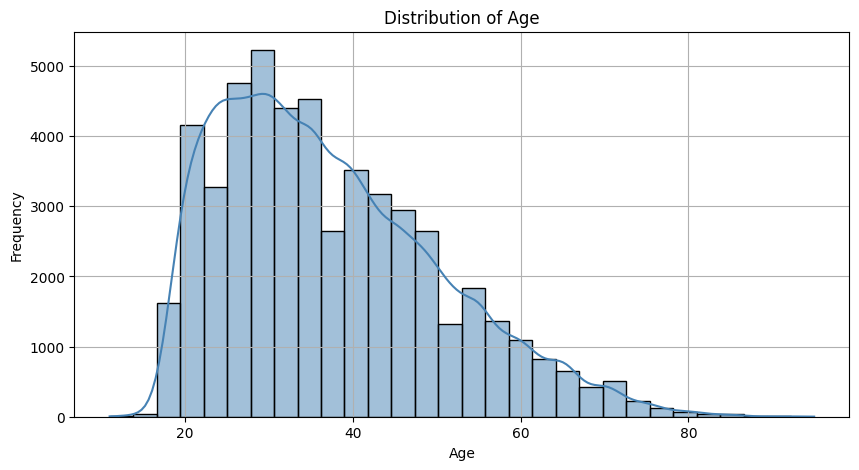

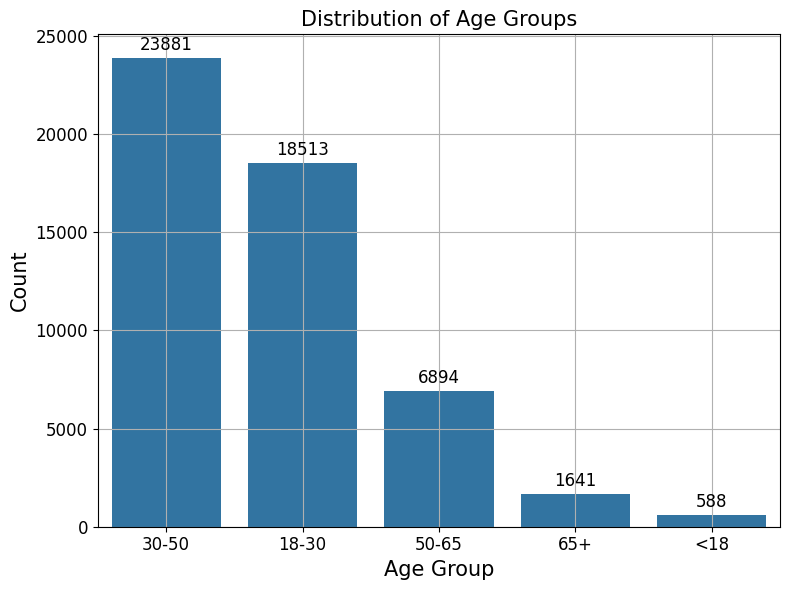

,age
count,51517.000000
mean,37.299532
std,13.112207
min,11.000000
25%,27.000000
50%,35.000000
75%,45.000000
95%,62.000000
max,95.000000


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Age Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['age'].dropna(), bins=30, kde=True, color='steelblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Age Group Bar Chart
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='age_group', data=df, order=df['age_group'].value_counts().index)
plt.title('Distribution of Age Groups',fontsize=15)
plt.xlabel('Age Group', fontsize=15) # Increased font size for x-axis label
plt.ylabel('Count', fontsize=15) # Increased font size for y-axis label
plt.grid(True)
plt.xticks(fontsize=12) # Added rotation for better readability of age groups and increased font size
plt.yticks(fontsize=12) # Increased font size for y-axis tick labels

# Add count labels above each bar, even for the smallest ones
for p in ax.patches:
    count = int(p.get_height())
    ax.annotate(f'{count}', (p.get_x() + p.get_width()/2, count),
                ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 3), # Increased fontsize to 14
                textcoords='offset points')
plt.tight_layout()
plt.show()

# Descriptive statistics for age
df['age'].describe(percentiles=[0.25, 0.5, 0.75, 0.95])

####  1.2 Bail Type, Outcome, Past Criminal Record, Withdrawal

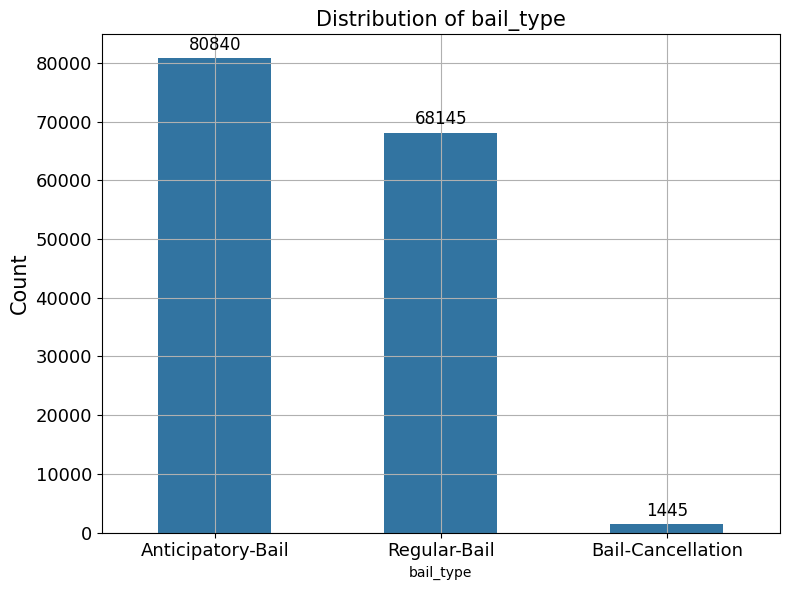


bail_type value counts:
 bail_type
Anticipatory-Bail    80840
Regular-Bail         68145
Bail-Cancellation     1445
Name: count, dtype: int64


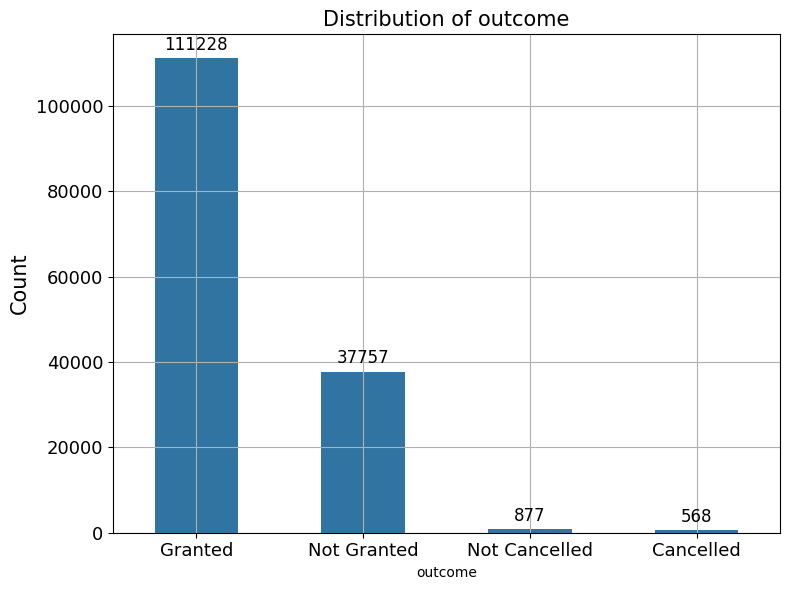


outcome value counts:
 outcome
Granted          111228
Not Granted       37757
Not Cancelled       877
Cancelled           568
Name: count, dtype: int64


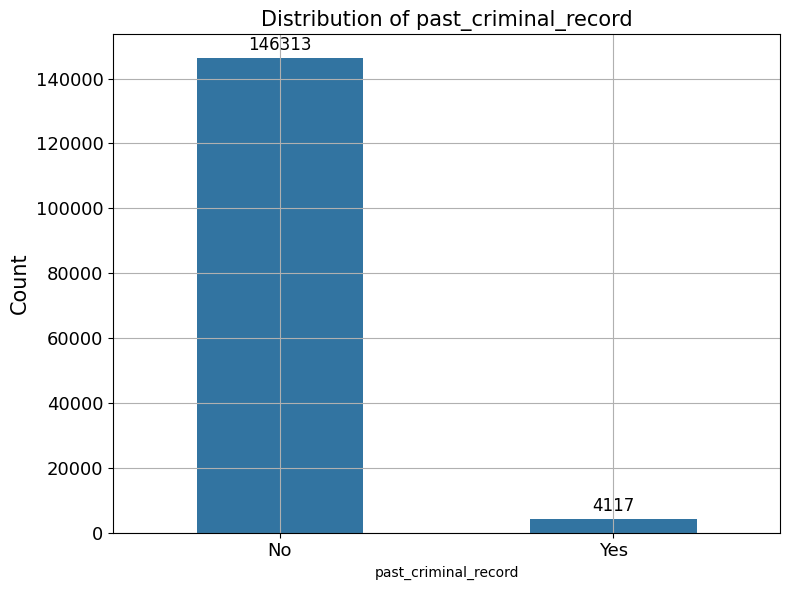


past_criminal_record value counts:
 past_criminal_record
No     146313
Yes      4117
Name: count, dtype: int64


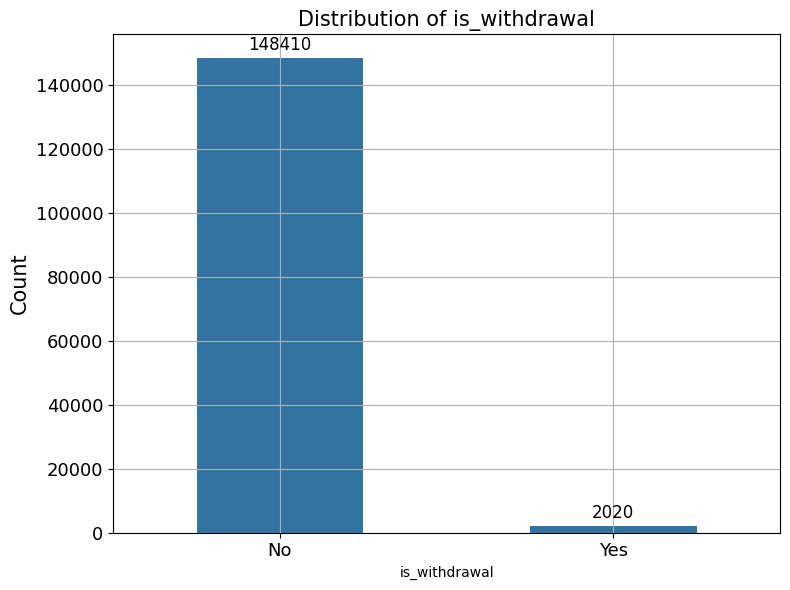


is_withdrawal value counts:
 is_withdrawal
No     148410
Yes      2020
Name: count, dtype: int64


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ['bail_type', 'outcome', 'past_criminal_record', 'is_withdrawal']
for col in categorical_cols:
    plt.figure(figsize=(8, 6))
    ax = sns.countplot(x=col, data=df, order=df[col].value_counts().index, width=0.5) # Adjusted width
    plt.title(f'Distribution of {col}',fontsize=15)
    plt.ylabel('Count',fontsize=15)
    plt.grid(True)
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)

    # Add count labels above each bar, even for the smallest ones
    for p in ax.patches:
        count = int(p.get_height())
        ax.annotate(f'{count}', (p.get_x() + p.get_width()/2, count),
                    ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 3),
                    textcoords='offset points')
    plt.tight_layout()
    plt.show()
    print(f"\n{col} value counts:\n", df[col].value_counts())

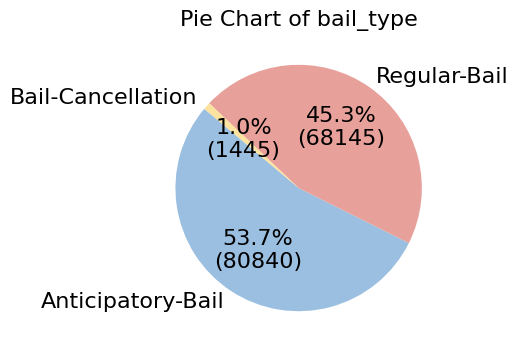

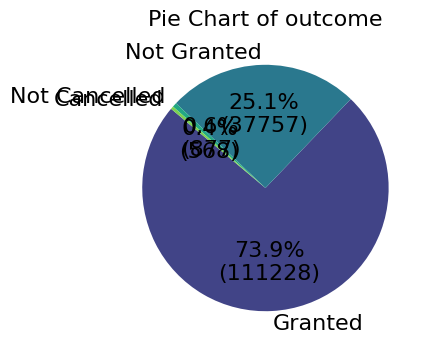

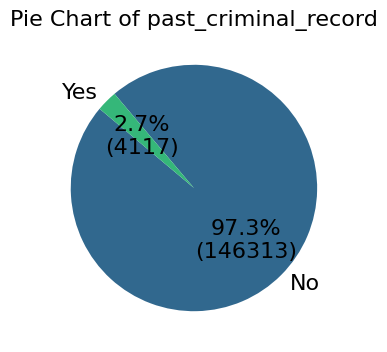

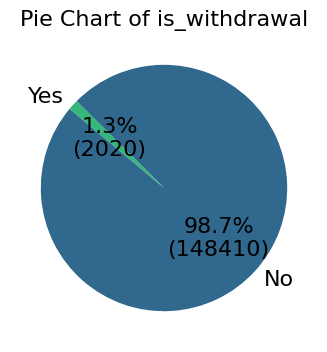

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Custom labels to display on pie (percentage)
def make_autopct(sizes):
    def my_autopct(pct):
        total = sum(sizes)
        val = int(round(pct*total/100.0))
        return f"{pct:.1f}%\n({val})"
    return my_autopct

      # Replace 'col' with your desired column, e.g., 'bail_type'
columns = ['bail_type', 'outcome', 'past_criminal_record', 'is_withdrawal']
for col in columns:
      # Value counts for labels and sizes
      counts = df[col].value_counts()
      labels = counts.index
      sizes = counts.values

      # Choose a beautiful color palette
      # colors = sns.color_palette('rocket', len(labels)) # Original color palette

      # Define custom colors based on user's request
      custom_colors = {
          'Anticipatory-Bail': '#9BBFE0',
          'Regular-Bail': '#E8A09A',
          'Bail-Cancellation': '#FBE29F',
          # Add other outcomes, past criminal record, and withdrawal colors if needed, or use a default palette for them
      }

      # Use custom colors if available for the current column, otherwise use a default palette
      if col == 'bail_type':
          colors = [custom_colors.get(label, 'gray') for label in labels] # Use gray for any missing labels
      else:
          colors = sns.color_palette('viridis', len(labels)) # Default palette for other columns


      plt.figure(figsize=(8, 4))
      patches, texts, autotexts = plt.pie(
          sizes,
          labels=labels,
          colors=colors,
          autopct=make_autopct(sizes),
          textprops={'fontsize': 16, 'color': 'black'}, # Increased fontsize to 14
          startangle=140,
          # wedgeprops={'edgecolor': 'black'}
      )

      # Customize the pie chart title
      plt.title(f"Pie Chart of {col}", fontsize=16)

      # Create legend with counts
      # legend_labels = [f"{label} ({count})" for label, count in zip(labels, sizes)]
      # plt.legend(patches, legend_labels, title='Count', bbox_to_anchor=(1, 0.95)) # Removed legend

      # plt.tight_layout()
      plt.show()

#### 1.3 Health Issues

In [ ]:
# Normalize case: lowercased strings for comparison
df['health_issues_clean'] = df['health_issues'].astype(str).str.strip().str.lower()

# Define patterns to exclude
excluded_values = ['not provided', 'none', 'nan', 'no', '']

# Filter valid health issues only
valid_health = df[~df['health_issues_clean'].isin(excluded_values)]

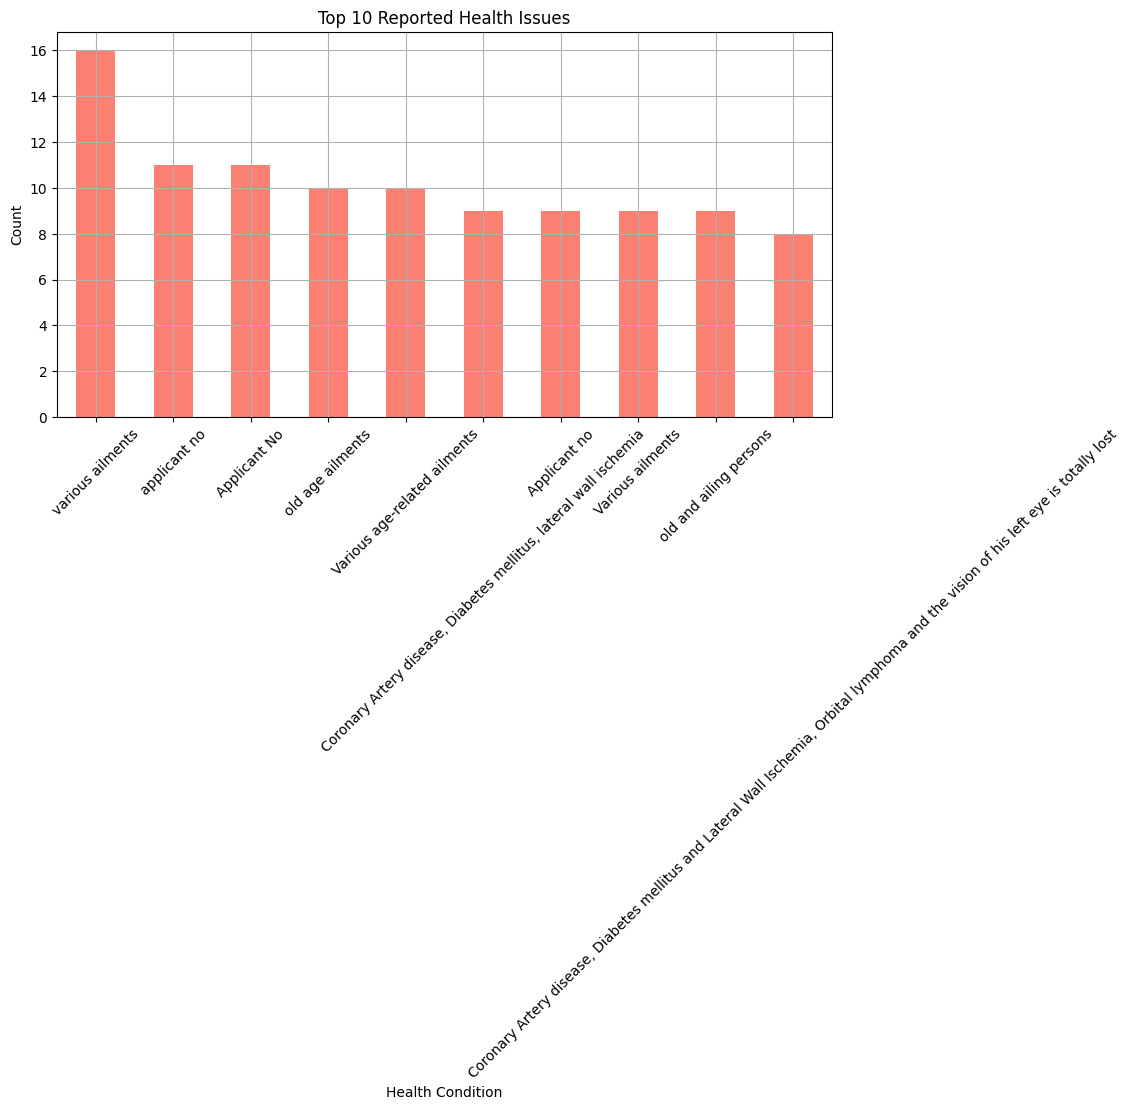

In [ ]:
# Health Issues (Top 15)
plt.figure(figsize=(10, 5))
valid_health['health_issues'].value_counts().head(10).plot(kind='bar', color='salmon')
plt.title('Top 10 Reported Health Issues')
plt.xlabel('Health Condition')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


#### 1.4 Statute Frequency

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150430 entries, 0 to 150429
Data columns (total 16 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   CNR                                150430 non-null  object        
 1   bail_type                          150430 non-null  object        
 2   is_withdrawal                      150430 non-null  object        
 3   age                                51517 non-null   float64       
 4   health_issues                      3686 non-null    object        
 5   past_criminal_record               150430 non-null  object        
 6   statutes                           150430 non-null  object        
 7   outcome                            150430 non-null  object        
 8   date_of_arrest                     43012 non-null   datetime64[ns]
 9   date_of_judgement                  147311 non-null  datetime64[ns]
 10  case_details_length 

/tmp/ipython-input-49-2857130140.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stat_df, y="Statute", x="Count", palette="tab10")


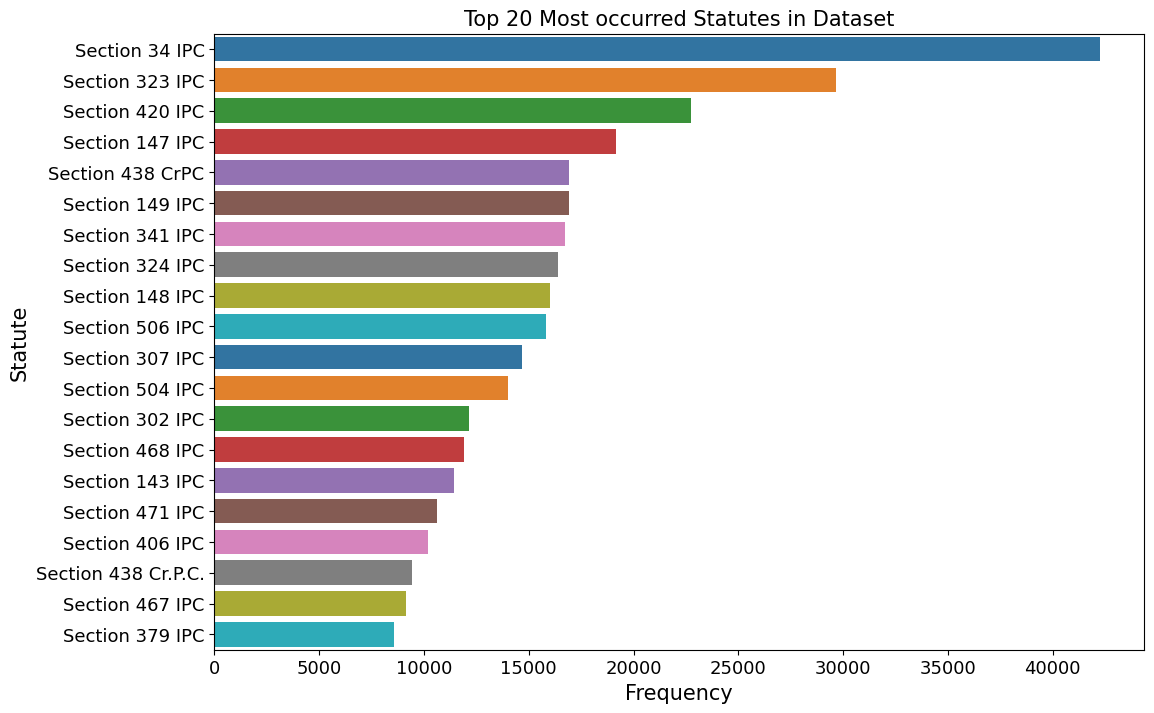

In [ ]:
from collections import Counter

# Flattened all statutes
all_statutes = df['statutes'].explode().dropna()
top_statutes = Counter(all_statutes).most_common(20)

# Create DataFrame for plotting
stat_df = pd.DataFrame(top_statutes, columns=["Statute", "Count"])

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(data=stat_df, y="Statute", x="Count", palette="tab10")
plt.title("Top 20 Most occurred Statutes in Dataset", fontsize=15)
plt.xlabel("Frequency",fontsize=15)
plt.ylabel("Statute",fontsize=15)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
# plt.grid(True)
plt.show()


#### 1.5 Case Detail Length & Statute Count

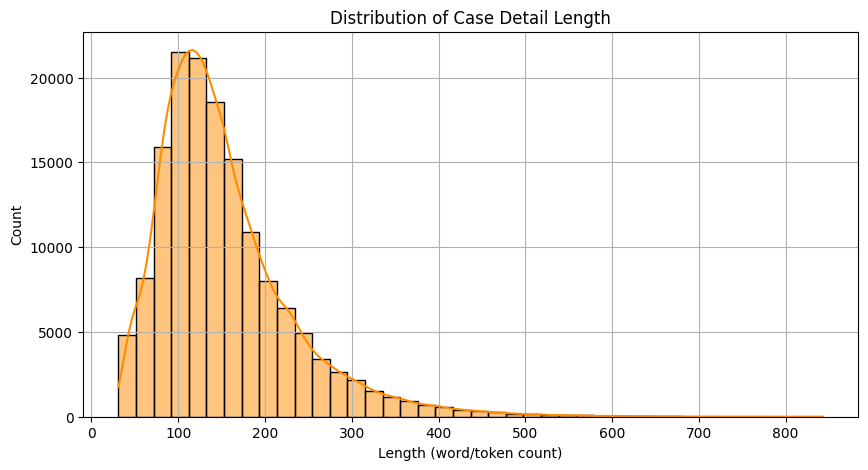

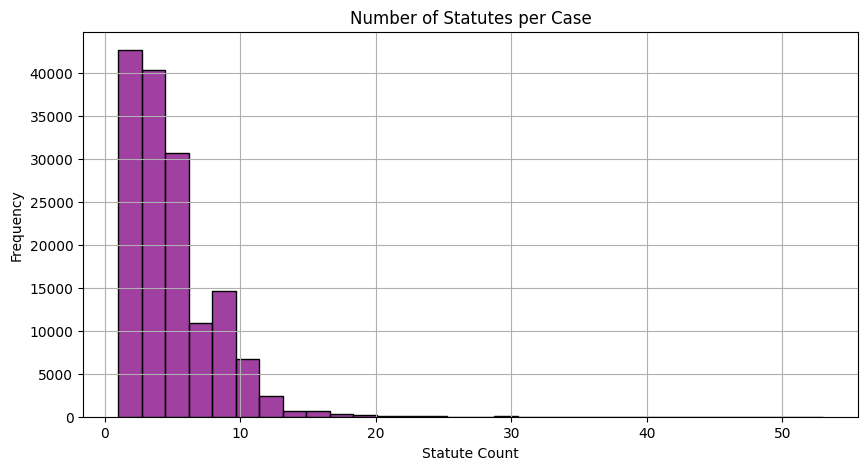

,case_details_length,num_statutes
count,150430.00000,150430.000000
mean,153.45237,4.708602
std,78.99624,3.171014
min,31.00000,1.000000
25%,100.00000,2.000000
50%,136.00000,4.000000
75%,187.00000,6.000000
max,843.00000,53.000000


In [ ]:
# Case Details Length Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['case_details_length'], bins=40, kde=True, color='darkorange')
plt.title('Distribution of Case Detail Length')
plt.xlabel('Length (word/token count)')
plt.ylabel('Count')
plt.grid(True)
plt.show()

# Statutes per Case
plt.figure(figsize=(10, 5))
sns.histplot(df['num_statutes'], bins=30, color='purple')
plt.title('Number of Statutes per Case')
plt.xlabel('Statute Count')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Summary
df[['case_details_length', 'num_statutes']].describe()


#### 1.6 Days Between Arrest and Judgement

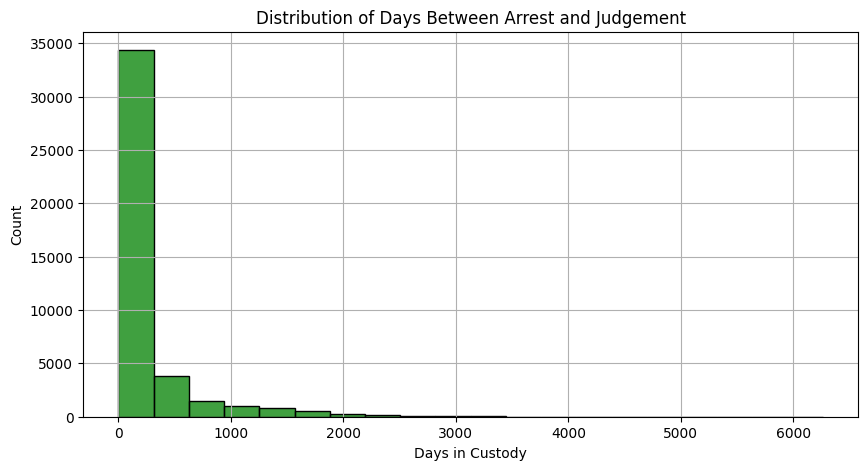

,days_between_arrest_and_judgement
count,42654.000000
mean,254.553617
std,439.215726
min,0.000000
25%,39.000000
50%,100.000000
75%,239.000000
95%,1209.000000
max,6262.000000


In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['days_between_arrest_and_judgement'].dropna(), bins=20, color='green')
plt.title('Distribution of Days Between Arrest and Judgement')
plt.xlabel('Days in Custody')
plt.ylabel('Count')
plt.grid(True)
plt.show()

# Summary stats
df['days_between_arrest_and_judgement'].describe(percentiles=[0.25, 0.5, 0.75, 0.95])


In [ ]:
max_days_index = df['days_between_arrest_and_judgement'].dropna().idxmax()
cnr_with_max_days = df.loc[max_days_index, 'CNR']
print(f"The CNR with the maximum days between arrest and judgement is: {cnr_with_max_days}")
df[df['CNR']=='UPHC011586532019']

The CNR with the maximum days between arrest and judgement is: UPHC011586532019


,CNR,bail_type,is_withdrawal,age,health_issues,past_criminal_record,statutes,outcome,date_of_arrest,date_of_judgement,case_details_length,Crime,age_group,num_statutes,days_between_arrest_and_judgement,health_issues_clean
17032,UPHC011586532019,Regular-Bail,No,NaN,NaN,No,"[Section 302 IPC, Section 323 IPC, Section 504...",Granted,2004-11-19,2022-01-11,199,White-collar crimes,NaN,3,6262.0,nan


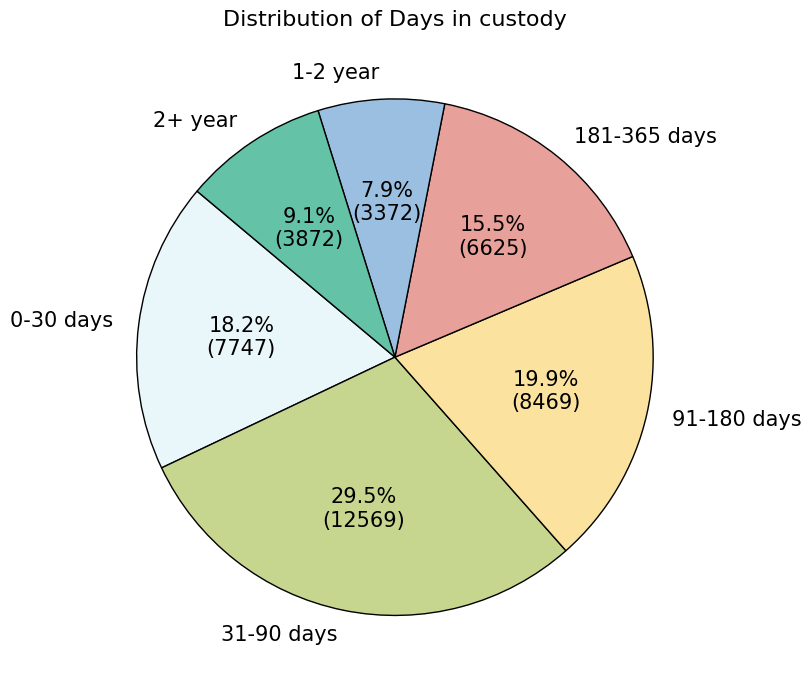

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Define bins and labels
bins = [0, 30, 90, 180, 365, 730,df['days_between_arrest_and_judgement'].max()]
labels = ['0-30 days', '31-90 days', '91-180 days', '181-365 days', '1-2 year','2+ year']

# Bin the data
df['days_bin'] = pd.cut(df['days_between_arrest_and_judgement'], bins=bins, labels=labels, right=True, include_lowest=True)

# Get counts per bin
counts = df['days_bin'].value_counts().sort_index()
sizes = counts.values
pie_labels = counts.index

# Autopct for percent + count display
def make_autopct(sizes):
    def my_autopct(pct):
        total = sum(sizes)
        val = int(round(pct*total/100.0))
        return f"{pct:.1f}%\n({val})"
    return my_autopct

# Choose a vibrant color palette
# colors = sns.color_palette('viridis', len(labels))
colors = ['#E9F6FA', '#C6D68F', '#FBE29F', '#E8A09A', '#9BBFE0', '#64C2A6']


plt.figure(figsize=(8, 7))
patches, texts, autotexts = plt.pie(
    sizes,
    labels=pie_labels,
    colors=colors,
    autopct=make_autopct(sizes),
    textprops={'fontsize': 15, 'color': 'black'},
    startangle=140,
    wedgeprops={'edgecolor': 'black'}
)

# Add title and legend
plt.title('Distribution of Days in custody', fontsize=16)
# legend_labels = [f"{label} ({count})" for label, count in zip(pie_labels, sizes)]
# plt.legend(patches, legend_labels, title='Count', bbox_to_anchor=(1, 0.95))

plt.tight_layout()
plt.show()

#### 1.7 Crimes

/tmp/ipython-input-54-1729036192.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stat_df, y="Crime", x="Count", palette="cubehelix") # Corrected y-axis label


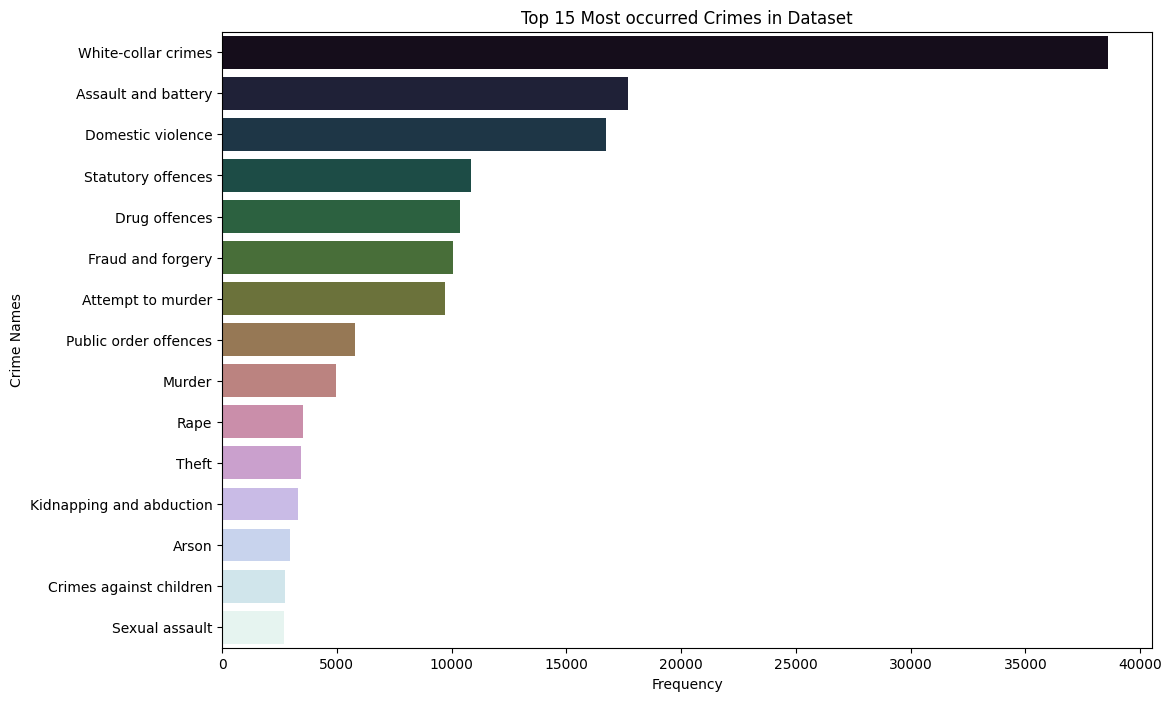

In [ ]:
from collections import Counter

# Flattened all statutes
all_statutes = df['Crime'].explode().dropna()
top_statutes = Counter(all_statutes).most_common(15) # Changed to top 15

# Create DataFrame for plotting
stat_df = pd.DataFrame(top_statutes, columns=["Crime", "Count"])

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(data=stat_df, y="Crime", x="Count", palette="cubehelix") # Corrected y-axis label
plt.title("Top 15 Most occurred Crimes in Dataset")
plt.xlabel("Frequency")
plt.ylabel("Crime Names")
# plt.grid(True)
plt.show()

# SECTION 2: Bivariate Analysis

#### 2.1 Bail Type vs Outcome

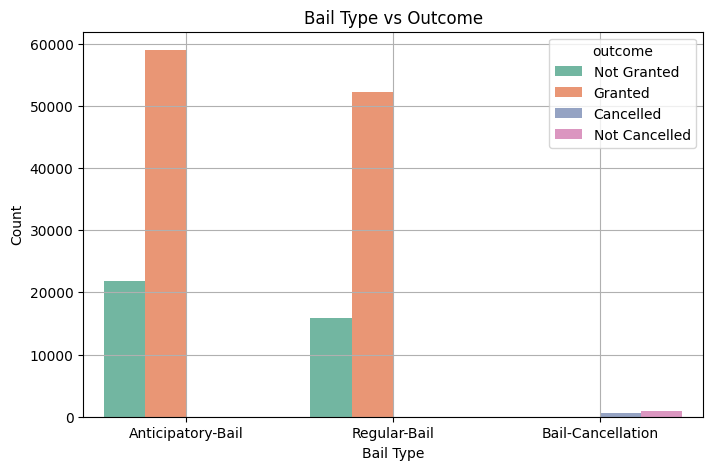

outcome,Cancelled,Granted,Not Cancelled,Not Granted
bail_type,,,,
Anticipatory-Bail,0.000000,72.930480,0.000000,27.069520
Bail-Cancellation,39.307958,0.000000,60.692042,0.000000
Regular-Bail,0.000000,76.705554,0.000000,23.294446


In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='bail_type', hue='outcome', palette='Set2')
plt.title('Bail Type vs Outcome')
plt.xlabel('Bail Type')
plt.ylabel('Count')
plt.grid(True)
plt.show()

# Crosstab for proportions
pd.crosstab(df['bail_type'], df['outcome'], normalize='index') * 100


In [ ]:
import pandas as pd

outcome_counts = pd.crosstab(df['bail_type'], df['outcome'])


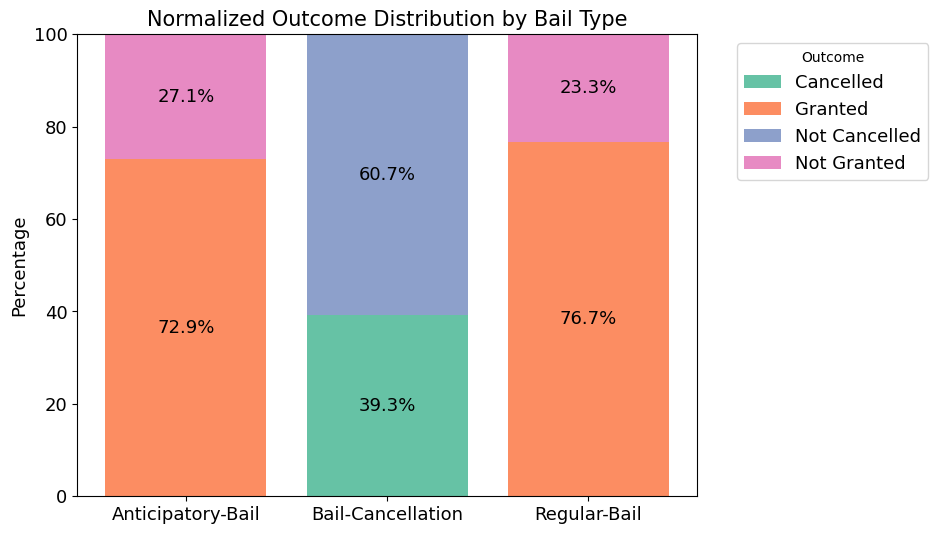

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Already created from your pie chart code:
# outcome_counts = df.groupby('bail_type')['outcome'].value_counts().unstack().fillna(0)
outcome_counts = pd.crosstab(df['bail_type'], df['outcome'])

# Normalize to percentage (row-wise)
outcome_percent = outcome_counts.div(outcome_counts.sum(axis=1), axis=0) * 100

# Plotting
labels = outcome_percent.index
outcome_types = outcome_percent.columns
colors = sns.color_palette('Set2', len(outcome_types))  # Consistent with pie chart

bottom = np.zeros(len(labels))

fig, ax = plt.subplots(figsize=(8, 6))
for i, outcome in enumerate(outcome_types):
    heights = outcome_percent[outcome].values
    ax.bar(labels, heights, bottom=bottom, label=outcome, color=colors[i])
    bottom += heights

# Customize
ax.set_ylabel('Percentage', fontsize=13)
ax.set_title('Normalized Outcome Distribution by Bail Type', fontsize=15)
ax.legend(title='Outcome', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=13) # Move legend outside and increase font size
ax.set_ylim(0, 100)

# Optional: Add percentage text inside bars
for i, bail_type in enumerate(labels):
    y_offset = 0
    for j, outcome in enumerate(outcome_types):
        pct = outcome_percent.loc[bail_type, outcome]
        if pct > 5:  # Only show if it's noticeable
            ax.text(i, y_offset + pct / 2, f"{pct:.1f}%", ha='center', va='center', fontsize=13)
        y_offset += pct

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.show()

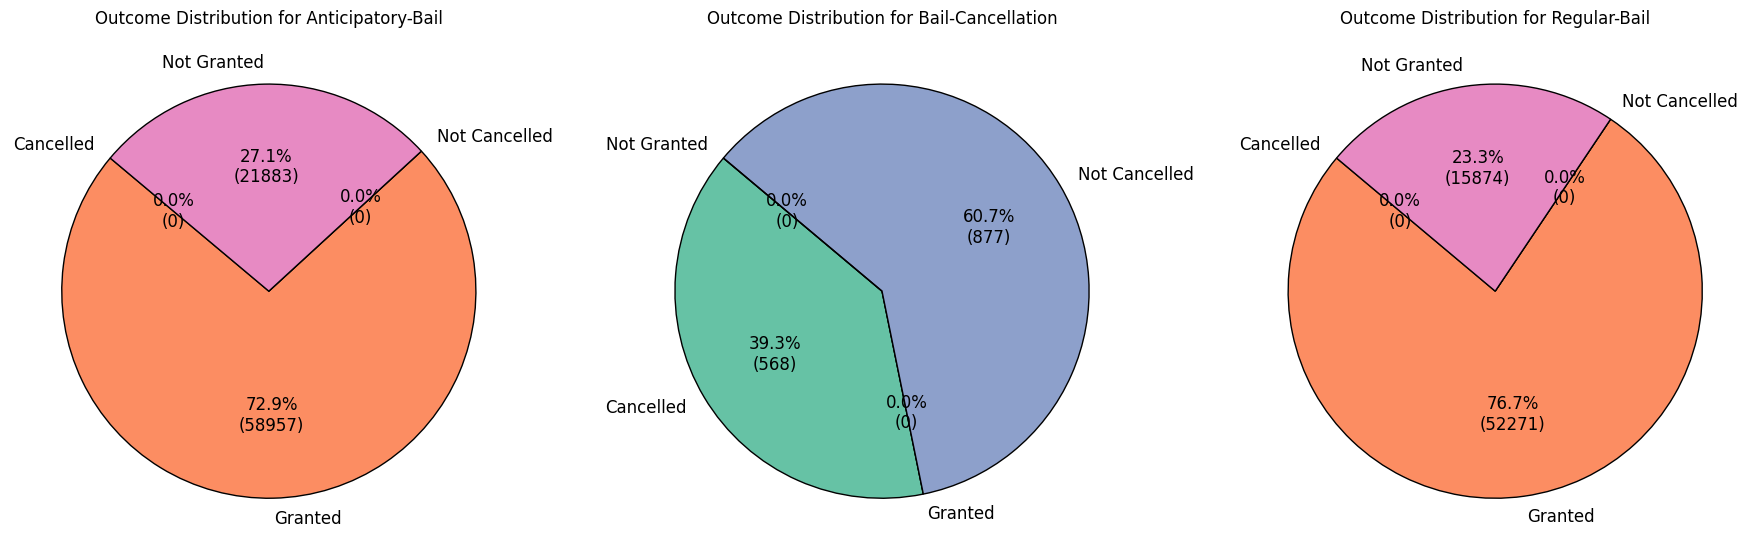

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

outcome_order = outcome_counts.columns  # Ensure consistent color mapping
colors = sns.color_palette('Set2', len(outcome_order))

# Create a single figure with subplots in a row
fig, axes = plt.subplots(1, len(outcome_counts), figsize=(6 * len(outcome_counts), 6)) # Adjust figsize based on number of plots
axes = axes.flatten()  # Flatten in case of a single plot

for idx, (bail_type, counts) in enumerate(outcome_counts.iterrows()):
    def make_autopct(values):
        def my_autopct(pct):
            total = sum(values)
            count = int(round(pct * total / 100.0))
            return f"{pct:.1f}%\n({count})"
        return my_autopct

    axes[idx].pie(
        counts.values,
        labels=counts.index,
        colors=colors,
        autopct=make_autopct(counts.values),
        textprops={'fontsize': 12, 'color': 'black'},
        startangle=140,
        wedgeprops={'edgecolor': 'black'}
    )
    # legend_labels = [f"{label} ({count})" for label, count in zip(counts.index, counts.values)]
    # axes[idx].legend(legend_labels, title='Outcome', bbox_to_anchor=(1, 0.95))
    axes[idx].set_title(f'Outcome Distribution for {bail_type}')

plt.tight_layout()
plt.show()

#### 2.2 Age Group vs Outcome

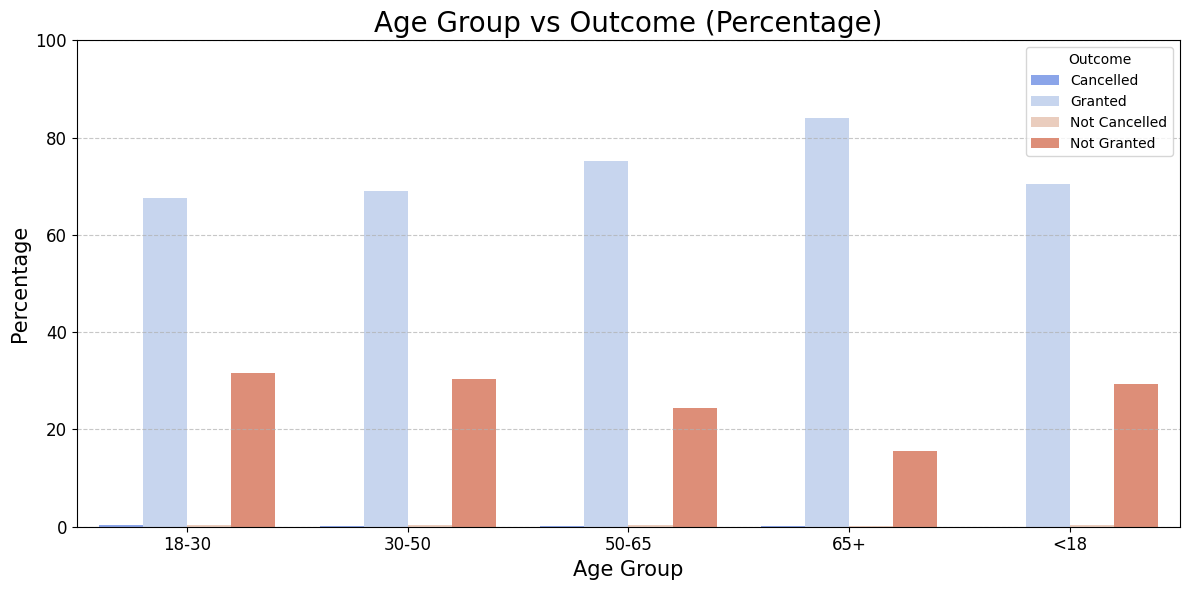

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Calculate percentage values
ct = pd.crosstab(df['age_group'], df['outcome'], normalize='index') * 100
df_percent = ct.reset_index().melt(id_vars='age_group', var_name='outcome', value_name='percentage')

# Step 2: Sort age groups if needed
df_percent['age_group'] = pd.Categorical(df_percent['age_group'], categories=sorted(df['age_group'].dropna().unique()), ordered=True)

# Step 3: Plot as grouped bar chart with percentages
plt.figure(figsize=(12, 6))
sns.barplot(data=df_percent, x='age_group', y='percentage', hue='outcome', palette='coolwarm')

# Customization
plt.title('Age Group vs Outcome (Percentage)', fontsize=20)
plt.xlabel('Age Group', fontsize=15)
plt.ylabel('Percentage', fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, 100)
plt.legend(title='Outcome')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


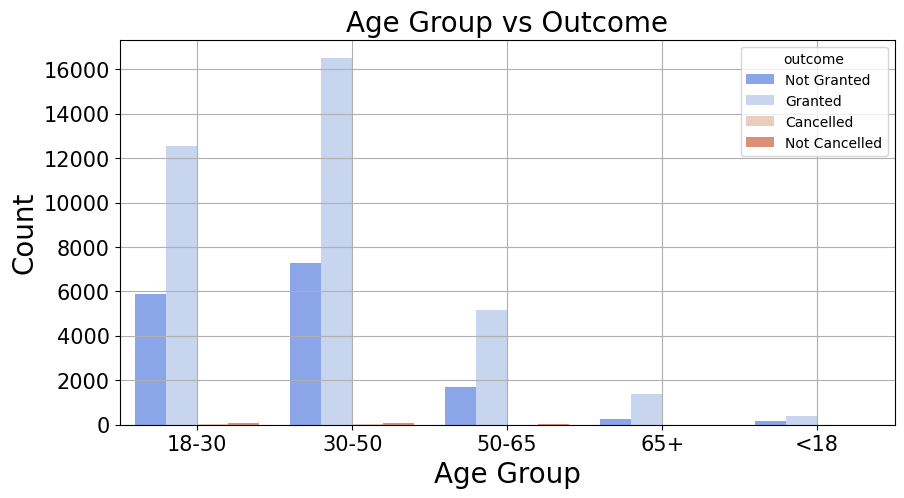

outcome,Cancelled,Granted,Not Cancelled,Not Granted
age_group,,,,
<18,0.000000,70.408163,0.340136,29.251701
18-30,0.270080,67.682169,0.356506,31.691244
30-50,0.188434,69.117709,0.301495,30.392362
50-65,0.116043,75.108790,0.275602,24.499565
65+,0.121877,84.095064,0.243754,15.539305


In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='age_group', hue='outcome', palette='coolwarm', order=sorted(df['age_group'].dropna().unique()))
plt.title('Age Group vs Outcome',fontsize=20)
plt.xlabel('Age Group',fontsize=20)
plt.ylabel('Count',fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.grid(True)
plt.show()

# Proportions
pd.crosstab(df['age_group'], df['outcome'], normalize='index') * 100


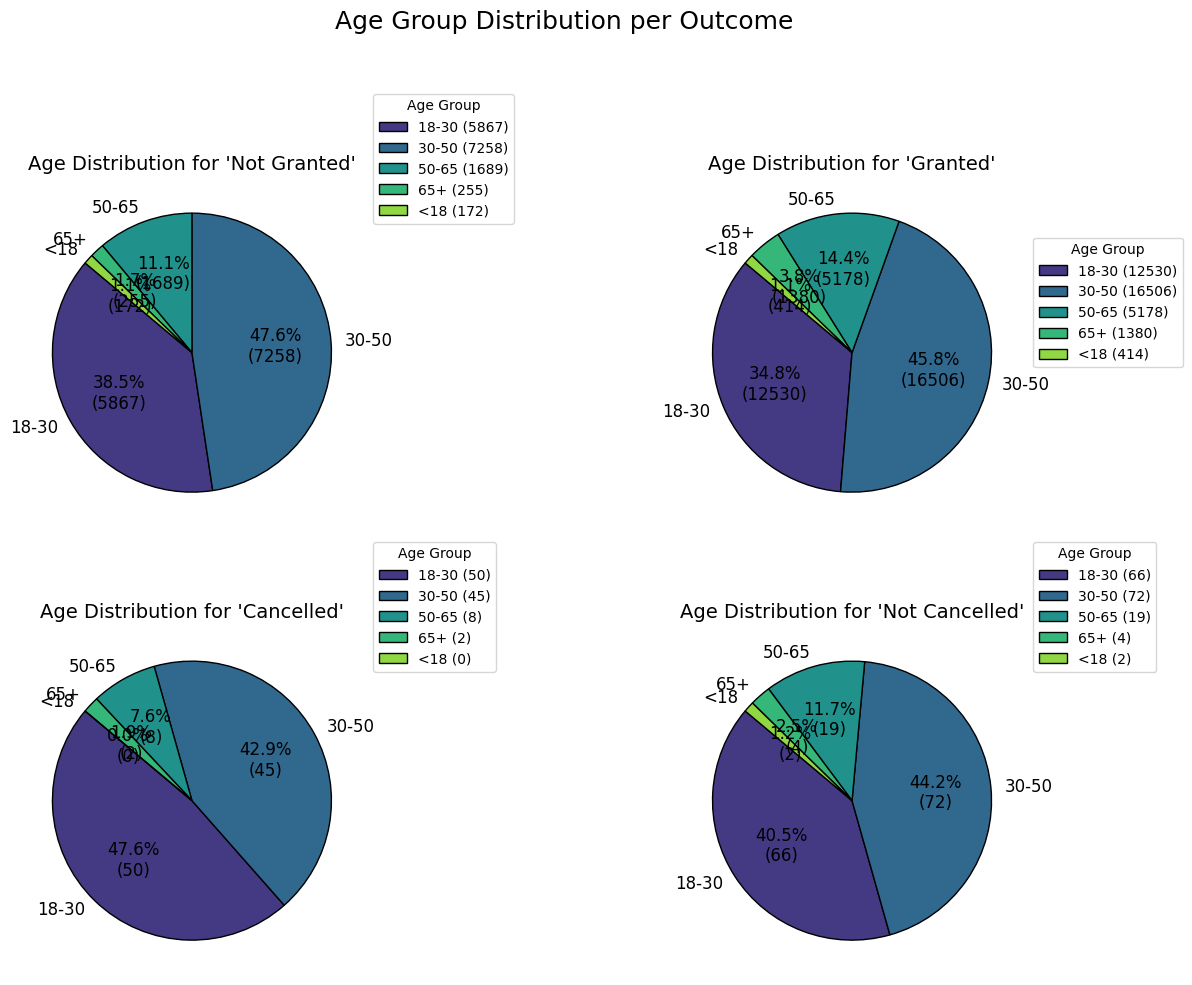

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get the unique outcome classes (ensure your column name is 'outcome')
outcome_classes = df['outcome'].dropna().unique()
age_bins = sorted(df['age_group'].dropna().unique())  # Ensure age bins are sorted

# Define a color palette for the age groups
colors = sns.color_palette('viridis', len(age_bins))

# Set up the 2x2 subplot structure (adjust nrows/ncols if not exactly four classes)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  # Easy indexing

for i, outcome in enumerate(outcome_classes):
    # Filter data for this outcome class
    temp = df[df['outcome'] == outcome]['age_group']
    # Count occurrences for each age group (set to 0 if missing)
    counts = temp.value_counts().reindex(age_bins, fill_value=0)

    # Set labels as "bin (count)"
    pie_labels = [f"{age} ({count})" for age, count in zip(age_bins, counts)]

    # Custom autopct to show percentage and count
    def make_autopct(values):
        def my_autopct(pct):
            total = sum(values)
            val = int(round(pct * total / 100.0))
            return f"{pct:.1f}%\n({val})"
        return my_autopct

    # Pie chart for this outcome
    wedges, texts, autotexts = axes[i].pie(
        counts,
        labels=age_bins,
        colors=colors,
        autopct=make_autopct(counts),
        textprops={'fontsize': 12, 'color': 'black'},
        startangle=140,
        wedgeprops={'edgecolor': 'black'}
    )
    axes[i].set_title(f"Age Distribution for '{outcome}'", fontsize=14)
    axes[i].legend(wedges, pie_labels, title="Age Group", bbox_to_anchor=(1, 0.85))

# Add a main title and adjust layout
plt.suptitle("Age Group Distribution per Outcome", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


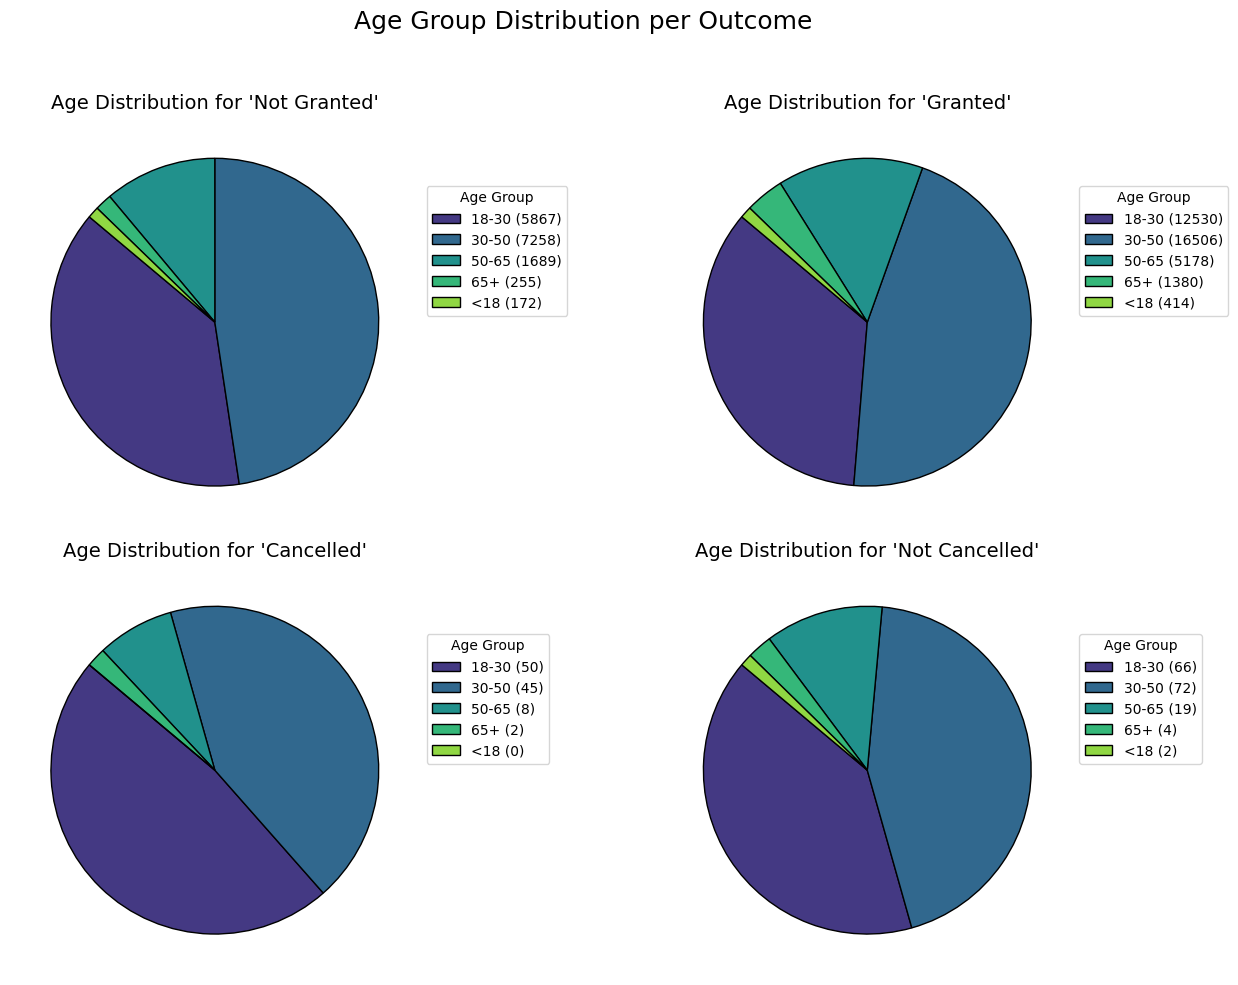

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Unique outcome and age bins (customize column names as needed)
outcome_classes = df['outcome'].dropna().unique()
age_bins = sorted(df['age_group'].dropna().unique())  # or your preferred order

# Choose a distinct palette for age bins
colors = sns.color_palette('viridis', len(age_bins))

# Subplots setup
fig, axes = plt.subplots(2, 2, figsize=(14, 10))  # Adjust if not 4 classes
axes = axes.flatten()

for i, outcome in enumerate(outcome_classes):
    # Get counts per age bin for this outcome
    temp = df[df['outcome'] == outcome]['age_group']
    counts = temp.value_counts().reindex(age_bins, fill_value=0)
    # Pie chart labels: empty, so nothing is on wedges
    labels = [''] * len(age_bins)
    # Legend labels: age bin with count
    legend_labels = [f"{age} ({count})" for age, count in zip(age_bins, counts)]
    # Pie chart
    wedges, _ = axes[i].pie(
        counts,
        labels=labels,  # no labels on slices
        colors=colors,
        startangle=140,
        wedgeprops={'edgecolor': 'black'}
    )
    axes[i].set_title(f"Age Distribution for '{outcome}'", fontsize=14)
    axes[i].legend(wedges, legend_labels, title="Age Group", bbox_to_anchor=(1, 0.85))

plt.suptitle("Age Group Distribution per Outcome", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


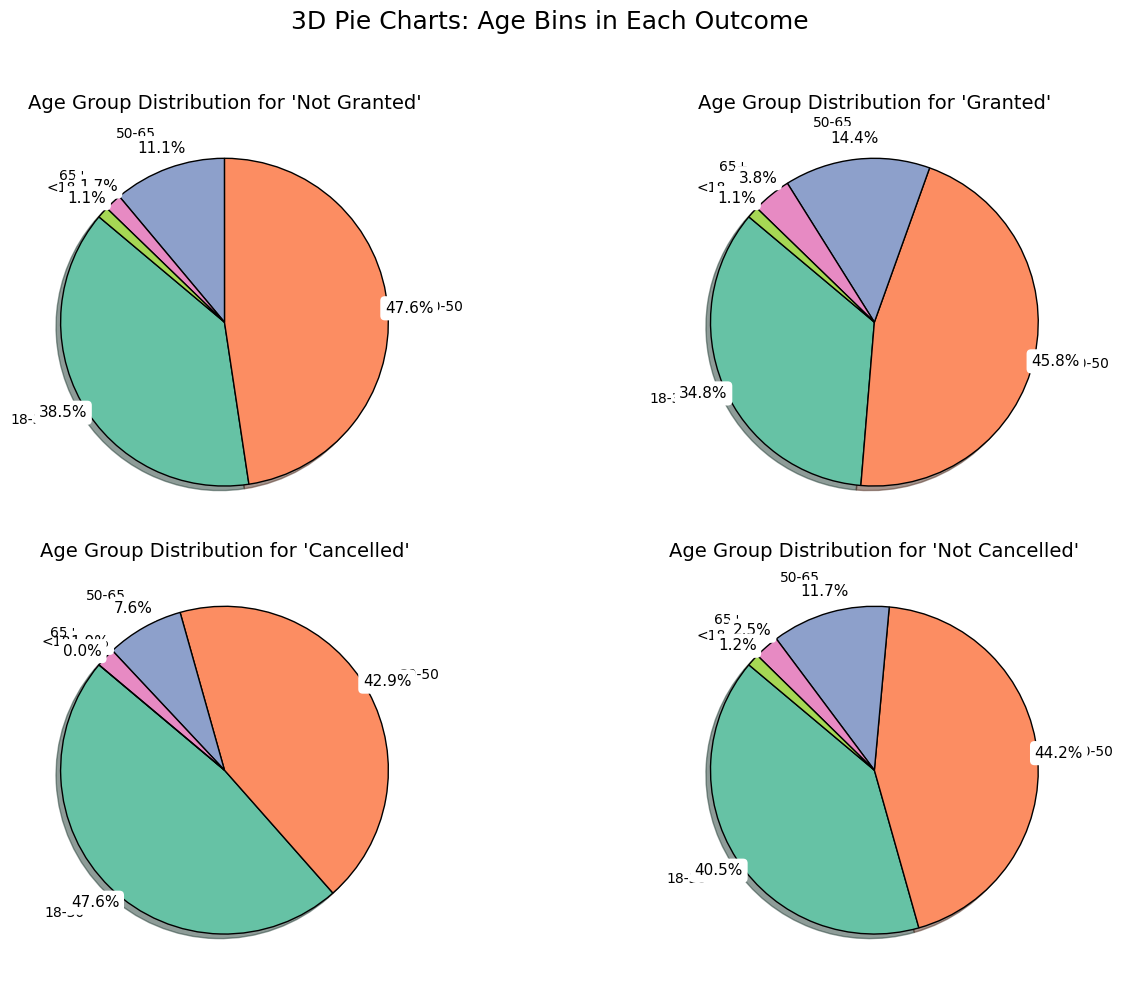

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Gather all unique classes and sorted age bins
outcome_classes = df['outcome'].dropna().unique()
age_bins = sorted(df['age_group'].dropna().unique())

# Pick a soft, readable color palette (Set2 or Pastel1)
colors = sns.color_palette('Set2', len(age_bins))

# Adjust subplot size if the number of classes changes (use nrows/ncols as needed)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))  # Adjust for your number of outcome classes
axes = axes.flatten()

for i, outcome in enumerate(outcome_classes):
    # Get counts for each age bin in this outcome
    temp = df[df['outcome'] == outcome]['age_group']
    counts = temp.value_counts().reindex(age_bins, fill_value=0)

    # Pie labels (category names) placed outside the pie
    labels = age_bins

    # Draw the "3D-like" pie chart with labels and percentages outside
    wedges, texts, autotexts = axes[i].pie(
        counts,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',         # Show percentage
        pctdistance=1.13,          # Percentage label further out
        labeldistance=1.22,        # Category label further out
        startangle=140,
        shadow=True,               # "3D" effect
        wedgeprops={'edgecolor': 'black'}
    )
    # Customize autotexts for clear reading
    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_fontsize(11)
        autotext.set_bbox(dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3'))

    axes[i].set_title(f"Age Group Distribution for '{outcome}'", fontsize=14)

# Main title and layout adjustments
plt.suptitle("3D Pie Charts: Age Bins in Each Outcome", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


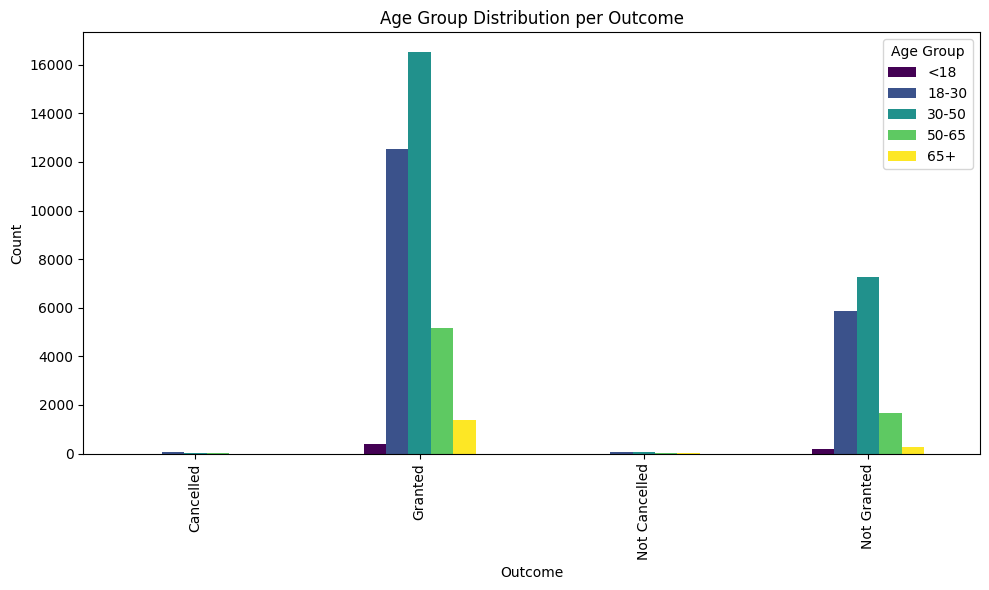

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Build the crosstab (adjust column names as needed)
ct = pd.crosstab(df['outcome'], df['age_group'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100  # Optionally, use as percent

# Plot grouped bar chart
ct.plot(kind='bar', figsize=(10, 6), colormap='viridis')  # for counts
# ct_pct.plot(kind='bar', figsize=(10, 6), colormap='viridis')  # for % share

plt.title('Age Group Distribution per Outcome')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.legend(title='Age Group')
plt.tight_layout()
plt.show()


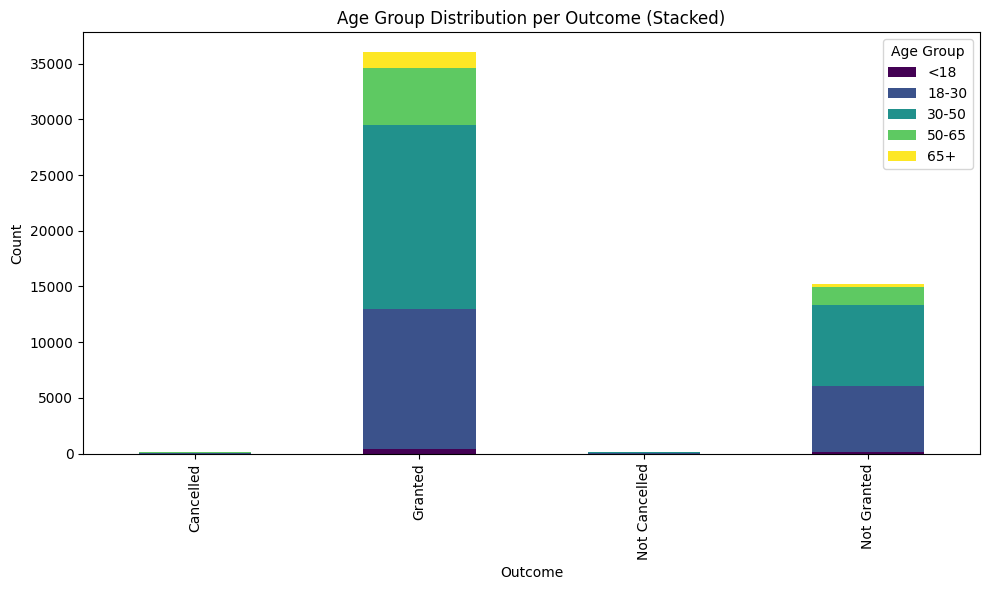

In [ ]:
# Stacked bar chart using the same crosstab
ct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Age Group Distribution per Outcome (Stacked)')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.legend(title='Age Group')
plt.tight_layout()
plt.show()


#### 2.3 Health Issues vs Outcome (Top 10 only)

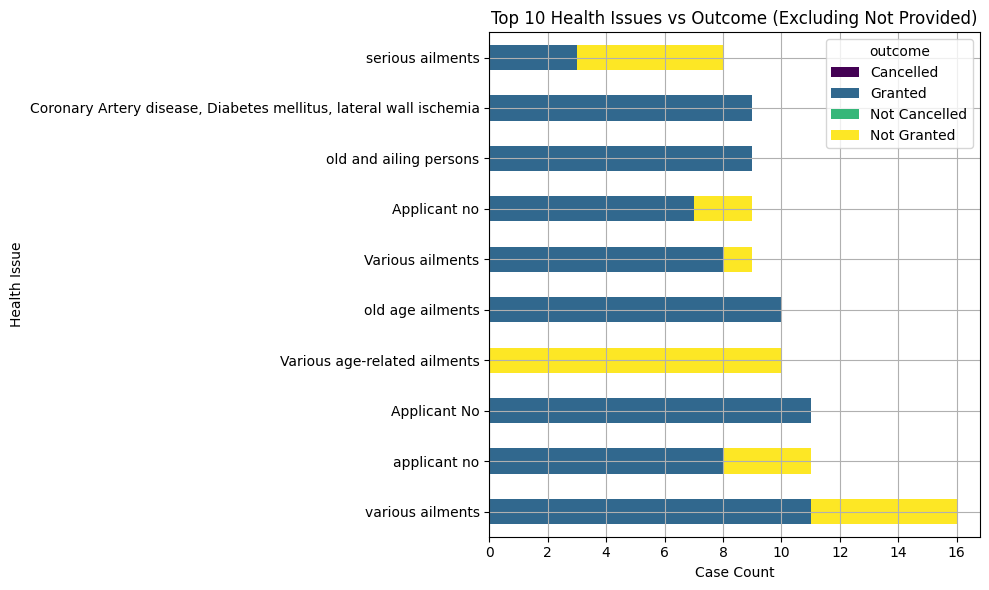

In [ ]:
# Group by and create stacked bar
health_outcome = valid_health.groupby(['health_issues', 'outcome']).size().unstack().fillna(0)

# Top 10 excluding "Not Provided"
top_health = health_outcome.sum(axis=1).sort_values(ascending=False).head(10).index
health_plot = health_outcome.loc[top_health]

# Plot
health_plot.plot(kind='barh', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Top 10 Health Issues vs Outcome (Excluding Not Provided)')
plt.xlabel('Case Count')
plt.ylabel('Health Issue')
plt.grid(True)
plt.tight_layout()
plt.show()


#### 2.4 Past Criminal Record vs Outcome

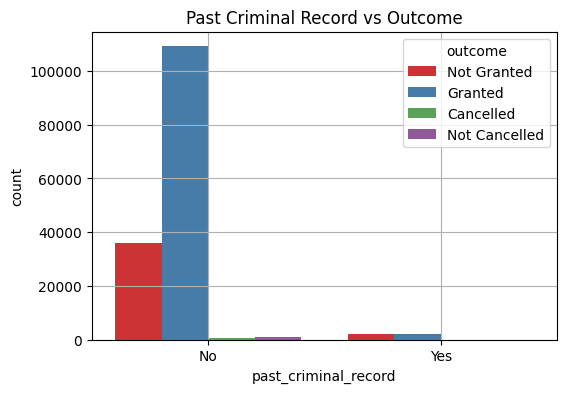

outcome,Cancelled,Granted,Not Cancelled,Not Granted
past_criminal_record,,,,
No,0.374540,74.592142,0.581630,24.451689
Yes,0.485791,50.765120,0.631528,48.117561


In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='past_criminal_record', hue='outcome', palette='Set1')
plt.title('Past Criminal Record vs Outcome')
plt.grid(True)
plt.show()

# Table
pd.crosstab(df['past_criminal_record'], df['outcome'], normalize='index') * 100


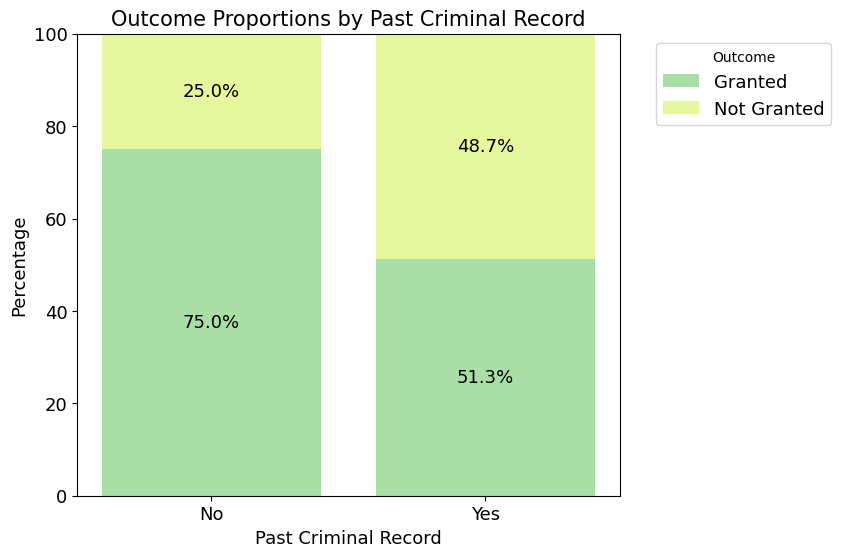

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Sample DataFrame (you can load your real one)
# df = pd.read_csv("your_file.csv")  # if loading from file

# Step 1: Filter and clean
df_filtered = df[df['past_criminal_record'].notna() & df['outcome'].notna()].copy()

# Step 2: Group 'past_criminal_record' into 'No' and 'Yes'
df_filtered['record_group'] = df_filtered['past_criminal_record'].apply(lambda x: 'No' if x.strip().lower() == 'no' else 'Yes')

# Step 3: Combine outcomes
df_filtered['simplified_outcome'] = df_filtered['outcome'].replace({
    'Cancelled': 'Granted',
    'Not Cancelled': 'Not Granted'
})

# Step 4: Get counts for simplified outcomes
grouped = df_filtered.groupby(['record_group', 'simplified_outcome']).size().unstack().fillna(0)

# Step 5: Normalize to percentage
percentages = grouped.div(grouped.sum(axis=1), axis=0) * 100

# Step 6: Plot
labels = percentages.index
outcome_types = percentages.columns
colors = ['#AADEA7', '#E6F69D']  # customize if needed

bottom = np.zeros(len(labels))

fig, ax = plt.subplots(figsize=(7, 6))
for i, outcome in enumerate(outcome_types):
    heights = percentages[outcome].values
    ax.bar(labels, heights, bottom=bottom, label=outcome, color=colors[i])

    # Add percentage labels
    for j, h in enumerate(heights):
        if h > 0:  # Only add label if percentage is greater than 0
            ax.text(j, bottom[j] + h / 2, f'{h:.1f}%', ha='center', va='center', color='black', fontsize=13)

    bottom += heights

# Decorate
ax.set_ylabel('Percentage', fontsize=13)
ax.set_xlabel('Past Criminal Record', fontsize=13)

ax.set_title('Outcome Proportions by Past Criminal Record', fontsize=15)
ax.legend(title='Outcome', bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=13) # Move legend outside
plt.ylim(0, 100)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.show()

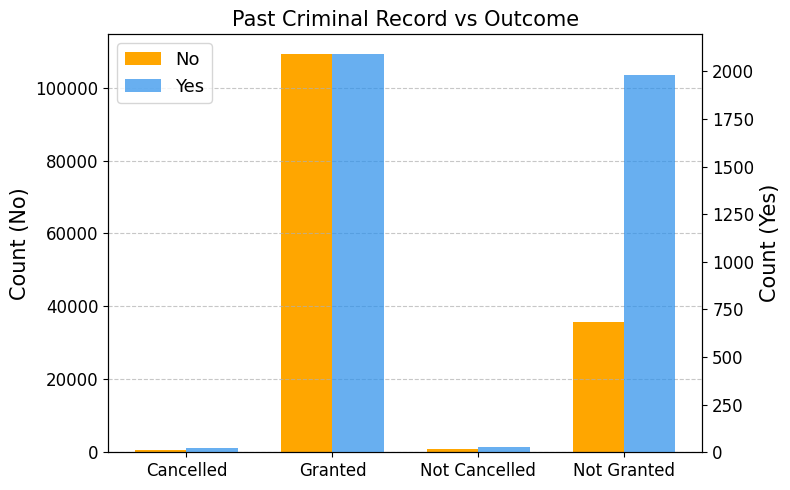

In [ ]:
from ctypes import alignment
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Prepare cross-tab for plotting
counts = pd.crosstab(df['past_criminal_record'], df['outcome'])

# Get positions and width for bars
outcomes = counts.columns.tolist()
x = np.arange(len(outcomes))
bar_width = 0.35

fig, ax1 = plt.subplots(figsize=(8, 5))

# Define custom colors
custom_colors = ['#ffa600', '#288eeb'] # Using the first two colors from the provided list

# Plot for "No" (left y-axis)
rects1 = ax1.bar(x - bar_width/2, counts.loc['No'], width=bar_width, label='No', color=custom_colors[0])
ax1.set_ylabel('Count (No)', fontsize=15)
ax1.set_xticks(x)
ax1.set_xticklabels(outcomes, fontsize=12)
ax1.tick_params(axis='y', labelsize=12)
ax1.set_title('Past Criminal Record vs Outcome', fontsize=15)
ax1.grid(True, axis='y', linestyle='--', alpha=0.7)

# Create second y-axis for "Yes"
ax2 = ax1.twinx()
rects2 = ax2.bar(x + bar_width/2, counts.loc['Yes'], width=bar_width, label='Yes', color=custom_colors[1], alpha=0.7)
ax2.set_ylabel('Count (Yes)', fontsize=15)
ax2.tick_params(axis='y', labelsize=12)

# Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, fontsize=13, loc='upper left', bbox_to_anchor=(0, 1)) # Adjusted legend position

plt.tight_layout()
plt.show()

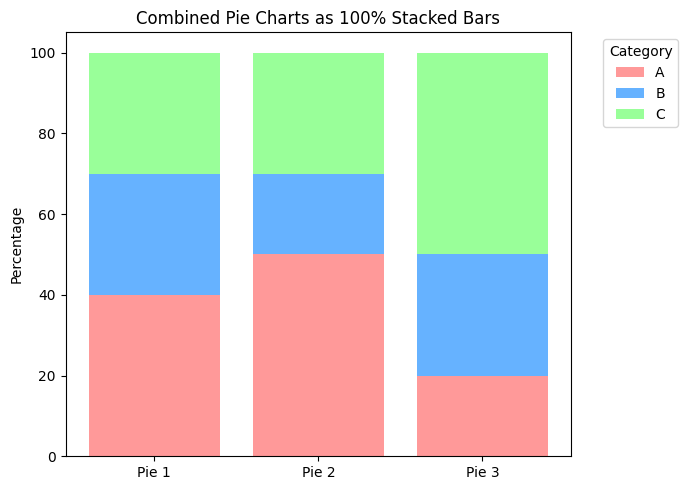

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data
categories = ['A', 'B', 'C']
pie1 = [40, 30, 30]
pie2 = [50, 20, 30]
pie3 = [20, 30, 50]

# Combine into matrix
data = np.array([pie1, pie2, pie3]).T  # shape: (categories, bars)
labels = ['Pie 1', 'Pie 2', 'Pie 3']
colors = ['#FF9999', '#66B2FF', '#99FF99']  # One color per category

# Create bar chart
fig, ax = plt.subplots(figsize=(7, 5))

bottom = np.zeros(3)  # Initial bottom at 0 for all bars
for i in range(len(categories)):
    ax.bar(labels, data[i], bottom=bottom, label=categories[i], color=colors[i])
    bottom += data[i]

# Customize
ax.set_ylabel('Percentage')
ax.set_title('Combined Pie Charts as 100% Stacked Bars')
ax.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


#### 2.5 Number of Statutes vs Outcome

/tmp/ipython-input-18-1933646478.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='outcome', y='num_statutes', palette='pastel')


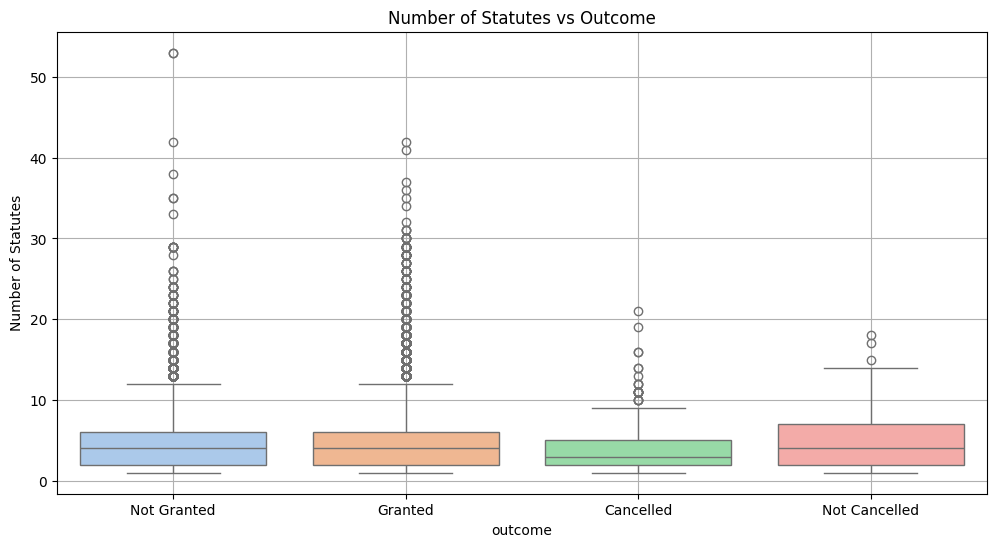

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='outcome', y='num_statutes', palette='pastel')
plt.title('Number of Statutes vs Outcome')
plt.ylabel('Number of Statutes')
plt.grid(True)
plt.show()


/tmp/ipython-input-52-2143438113.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=means, x='outcome', y='num_statutes', palette='pastel', ci='sd')
/tmp/ipython-input-52-2143438113.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=means, x='outcome', y='num_statutes', palette='pastel', ci='sd')


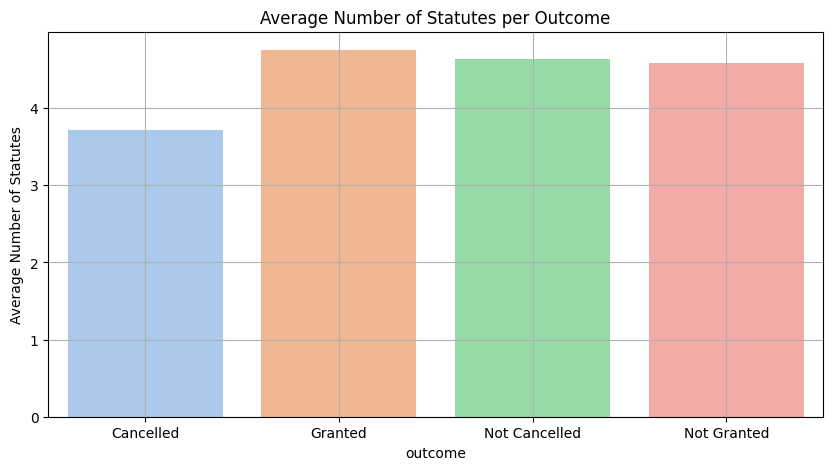

In [ ]:
means = df.groupby('outcome')['num_statutes'].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(data=means, x='outcome', y='num_statutes', palette='pastel', ci='sd')
plt.title('Average Number of Statutes per Outcome')
plt.ylabel('Average Number of Statutes')
plt.grid(True)
plt.show()


#### 2.6 Case Details Length vs Outcome

/tmp/ipython-input-81-1070014092.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='outcome', y='case_details_length', palette='cool')


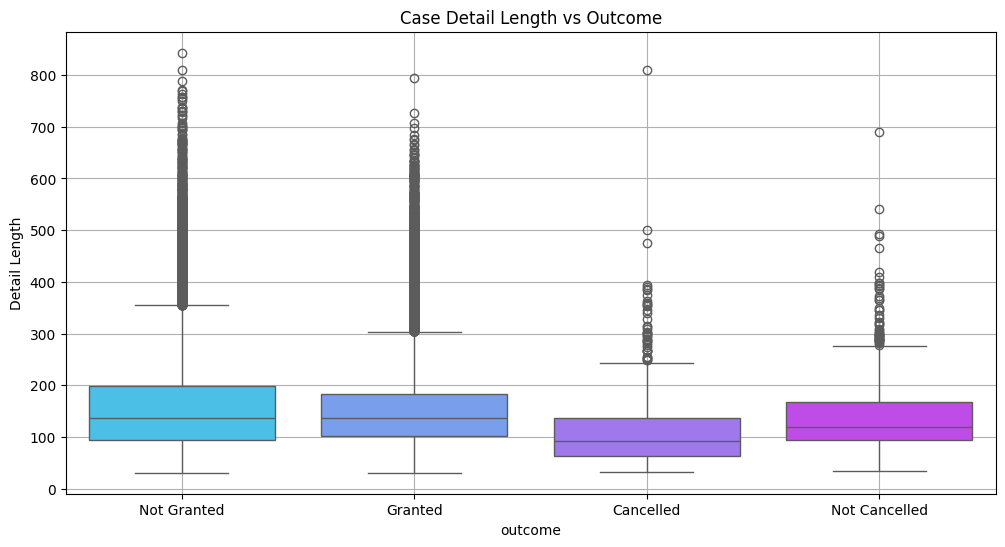

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='outcome', y='case_details_length', palette='cool')
plt.title('Case Detail Length vs Outcome')
plt.ylabel('Detail Length')
plt.grid(True)
plt.show()


#### 2.7 Days in Custody vs Outcome

/tmp/ipython-input-58-1069842710.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=means,


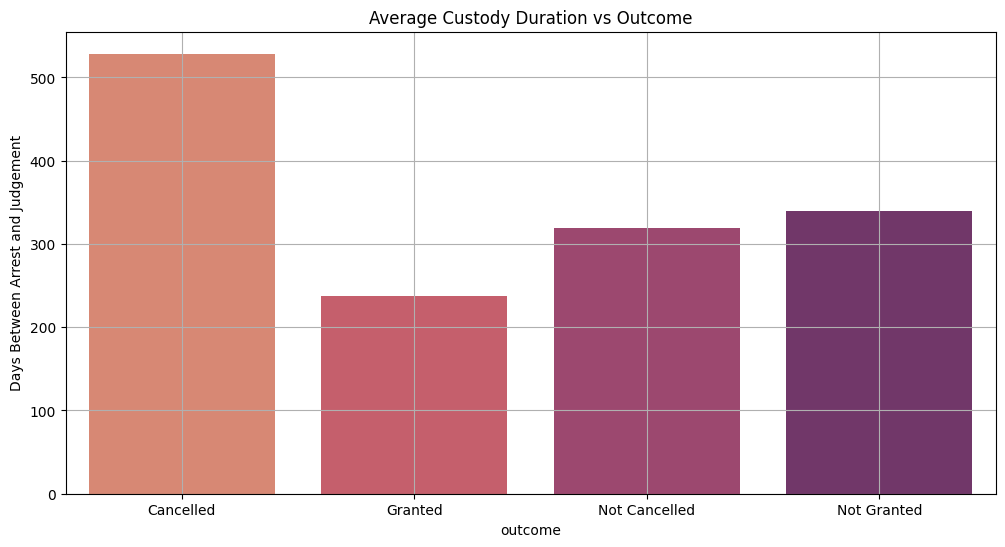

In [ ]:
means = df.groupby('outcome')['days_between_arrest_and_judgement'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=means,
            x='outcome', y='days_between_arrest_and_judgement', palette='flare')
plt.title('Average Custody Duration vs Outcome')
plt.ylabel('Days Between Arrest and Judgement')
plt.grid(True)
plt.show()


####  2.8 Top 10 Statutes vs Outcome Split

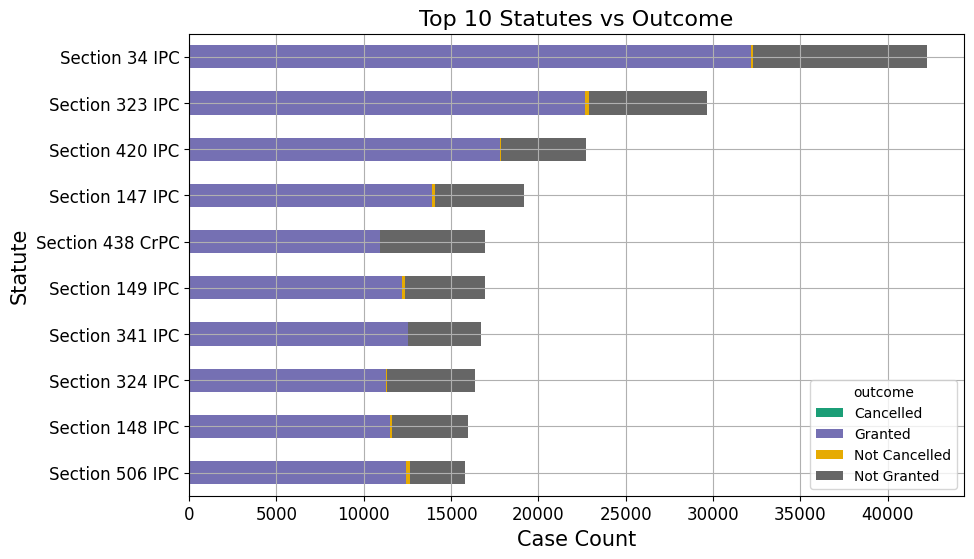

outcome,Cancelled,Granted,Not Cancelled,Not Granted
statutes,,,,
Section 506 IPC,0.530940,78.136654,1.213577,20.118829
Section 148 IPC,0.293860,71.520570,0.812805,27.372765
Section 324 IPC,0.134212,68.649341,0.445339,30.771108
Section 341 IPC,0.095745,74.836934,0.203459,24.863862
Section 149 IPC,0.271611,71.852858,0.714454,27.161077
Section 438 CrPC,0.000000,64.500325,0.005903,35.493773
Section 147 IPC,0.317924,72.304164,0.792203,26.585709
Section 420 IPC,0.136354,78.113042,0.431053,21.319551
Section 323 IPC,0.225962,76.300968,0.620552,22.852518


In [ ]:
# Explode and merge statute with outcome
exploded = df[['statutes', 'outcome']].explode('statutes').dropna()
statute_counts = exploded['statutes'].value_counts().head(10).index

top_statutes = exploded[exploded['statutes'].isin(statute_counts)]
top_statutes_ct = pd.crosstab(top_statutes['statutes'], top_statutes['outcome'])

# Order the statutes by total count in ascending order
top_statutes_ct['Total'] = top_statutes_ct.sum(axis=1)
top_statutes_ct = top_statutes_ct.sort_values(by='Total', ascending=True).drop(columns='Total')


top_statutes_ct.plot(kind='barh', stacked=True, figsize=(10, 6), colormap='Dark2')
plt.title("Top 10 Statutes vs Outcome", fontsize=16)
plt.ylabel("Statute", fontsize=15)
plt.xlabel("Case Count",fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.show()

# Optional: probability (percentage split)
top_statutes_ratio = top_statutes_ct.div(top_statutes_ct.sum(axis=1), axis=0) * 100
top_statutes_ratio

In [ ]:
# Explode statutes per row
exploded_stats = df[['statutes', 'outcome']].explode('statutes').dropna()
exploded_stats.loc[exploded_stats['statutes'] == 'Section 41A of the Abkari Act', 'statutes'] = 'Section 41A Abkari Act'
exploded_stats.loc[exploded_stats['statutes'] == 'Section 18 of the Scheduled Castes and Scheduled Tribes (Prevention of Atrocities) Act', 'statutes'] = 'Section 18 of the SC/ST Act'
exploded_stats = exploded_stats[exploded_stats['outcome'].isin(['Granted', 'Not Granted'])]

# Group by statute
statute_summary = exploded_stats.groupby('statutes')['outcome'].value_counts().unstack().fillna(0)

# Add total and grant rate
statute_summary['Total'] = statute_summary.sum(axis=1)
statute_summary['Grant Rate (%)'] = (statute_summary['Granted'] / statute_summary['Total']) * 100

# Filter: only statutes with at least 30 cases
filtered_statutes = statute_summary[statute_summary['Total'] >= 30]

# Top 10 by grant rate
top10_grant = filtered_statutes.sort_values('Grant Rate (%)', ascending=False).head(10)

# Bottom 10 by grant rate
bottom10_grant = filtered_statutes.sort_values('Grant Rate (%)', ascending=True).head(10)


In [ ]:
exploded_stats = df[['statutes', 'outcome']].explode('statutes').dropna()

In [ ]:
exploded_stats[exploded_stats['statutes']=='Section 41A of the Abkari Act']

,statutes,outcome


In [ ]:
exploded_stats.loc[exploded_stats['statutes'] == 'Section 41A of the Abkari Act', 'statutes'] = 'Section 41A Abkari Act'

In [ ]:
import pandas as pd
import re

# Example: If your data is already loaded
# bottom10_grant = pd.read_csv("your_input.csv")  # or however you load your data

special_map = {
    "Section 438 of Code of Criminal Procedure": "Section 438 CrPC",
    "Section 82 CrPC": "Section 82 CrPC",
    "Section 83 CrPC": "Section 83 CrPC",
    "Section 21 of the Kerala Protection of River Banks and Regulation of Removal of Sand Act": "Section 21 Kerela River Protection Act"
}

def reformat_statute(statute):
    # Check for special mapping first
    if statute in special_map:
        return special_map[statute]
    # Remove 'of the' and 'of'
    statute = re.sub(r' of the ', ' ', statute)
    statute = re.sub(r' of ', ' ', statute)
    # Change Cr.P.C. to CrPC
    statute = statute.replace("Cr.P.C.", "CrPC")
    # Remove redundant whitespace
    statute = re.sub(r'\s+', ' ', statute).strip()
    return statute

# Reset the index to make 'statutes' a column
bottom10_grant = bottom10_grant.reset_index()

# Apply reformatting to the 'statutes' column
bottom10_grant['statutes'] = bottom10_grant['statutes'].apply(reformat_statute)

# To view the result
print(bottom10_grant)

outcome                                statutes  Granted  Not Granted  Total  \
0                         Section 64 Abkari Act      0.0         33.0   33.0   
1                 Section 41A(b)(ii) Abkari Act      0.0         70.0   70.0   
2                        Section 41A Abkari Act     12.0        159.0  171.0   
3                          Section 18 SC/ST Act     17.0         75.0   92.0   
4                              Section 437 CrPC     22.0         91.0  113.0   
5                          Section 8 Abkari Act      7.0         26.0   33.0   
6                              Section 438 CrPC     35.0         93.0  128.0   
7                               Section 82 CrPC     66.0        172.0  238.0   
8                               Section 83 CrPC     33.0         76.0  109.0   
9        Section 21 Kerela River Protection Act     12.0         27.0   39.0   

outcome  Grant Rate (%)  
0              0.000000  
1              0.000000  
2              7.017544  
3             1

/tmp/ipython-input-91-3905689520.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Grant Rate (%)', y='statutes', data=bottom10_grant, palette='tab10')


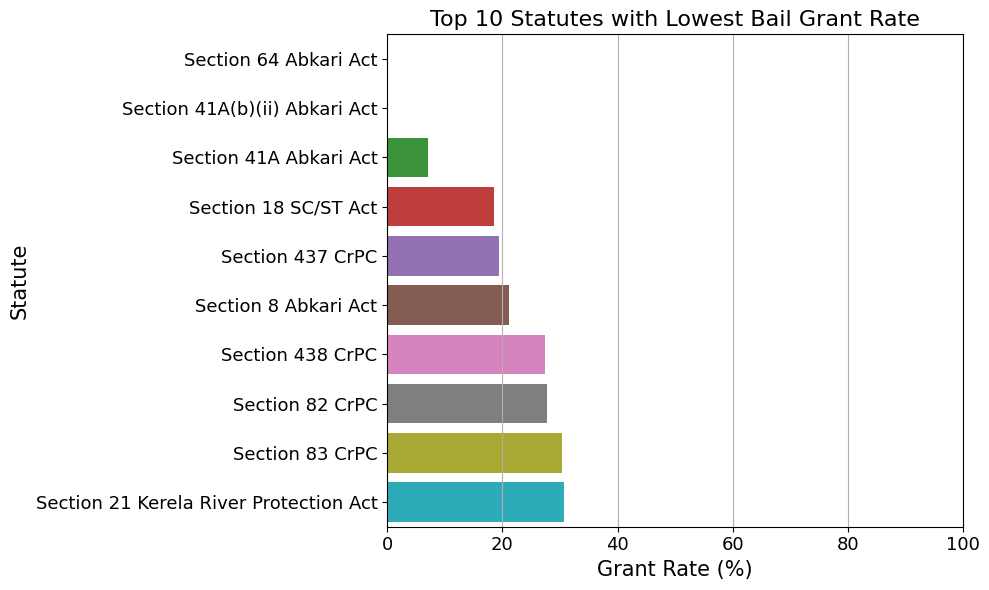

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Grant Rate (%)', y='statutes', data=bottom10_grant, palette='tab10')
plt.title('Top 10 Statutes with Lowest Bail Grant Rate',fontsize=16)
plt.xlabel('Grant Rate (%)',fontsize=15)
plt.ylabel('Statute',fontsize=15)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlim(0, 100)
plt.grid(axis='x')
plt.tight_layout()
plt.show()

In [ ]:
top10_grant

outcome,Granted,Not Granted,Total,Grant Rate (%)
statutes,,,,
Section 8 Jharkhand Sales Rule,31.0,0.0,31.0,100.0
Section 438(2) Cr. P.C.,156.0,0.0,156.0,100.0
Section 4/54 JMMC Rules,30.0,0.0,30.0,100.0
Section 54 JMMC Rule,42.0,0.0,42.0,100.0
Section 9 Jharkhand Sales Rule,31.0,0.0,31.0,100.0
Section 56(b) Abkari Act,40.0,0.0,40.0,100.0
Section 122 MV Act,55.0,0.0,55.0,100.0
Section 127 MV Act,36.0,0.0,36.0,100.0
Section 26/35 Arms Act,34.0,0.0,34.0,100.0


/tmp/ipython-input-58-2963067301.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Grant Rate (%)', y=top10_grant.index, data=top10_grant, palette='Greens_r')


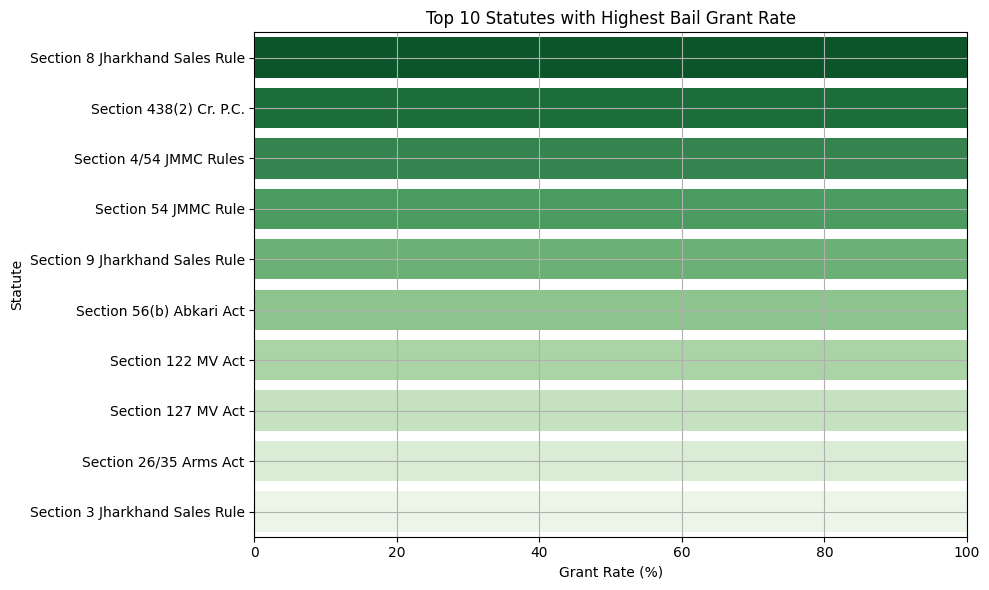

In [ ]:
 plt.figure(figsize=(10, 6))
sns.barplot(x='Grant Rate (%)', y=top10_grant.index, data=top10_grant, palette='Greens_r')
plt.title('Top 10 Statutes with Highest Bail Grant Rate')
plt.xlabel('Grant Rate (%)')
plt.ylabel('Statute')
plt.xlim(0, 100)
plt.grid(True)
plt.tight_layout()
plt.show()


/tmp/ipython-input-79-3624089222.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Grant Rate (%)', y=bottom10_grant.index, data=bottom10_grant, palette='Reds')


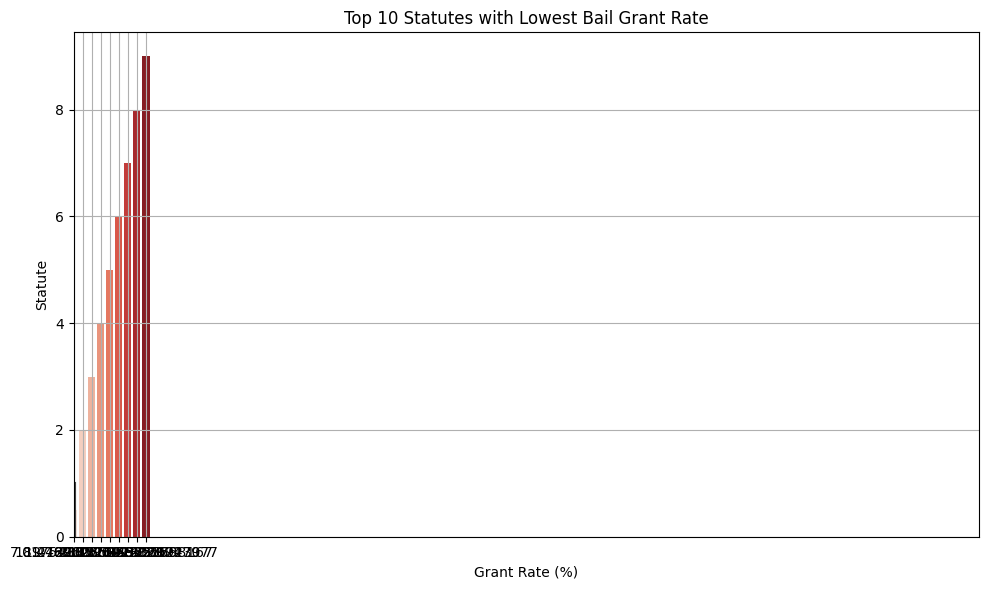

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Grant Rate (%)', y=bottom10_grant.index, data=bottom10_grant, palette='Reds')
plt.title('Top 10 Statutes with Lowest Bail Grant Rate')
plt.xlabel('Grant Rate (%)')
plt.ylabel('Statute')
plt.xlim(0, 100)
plt.grid(True)
plt.tight_layout()
plt.show()


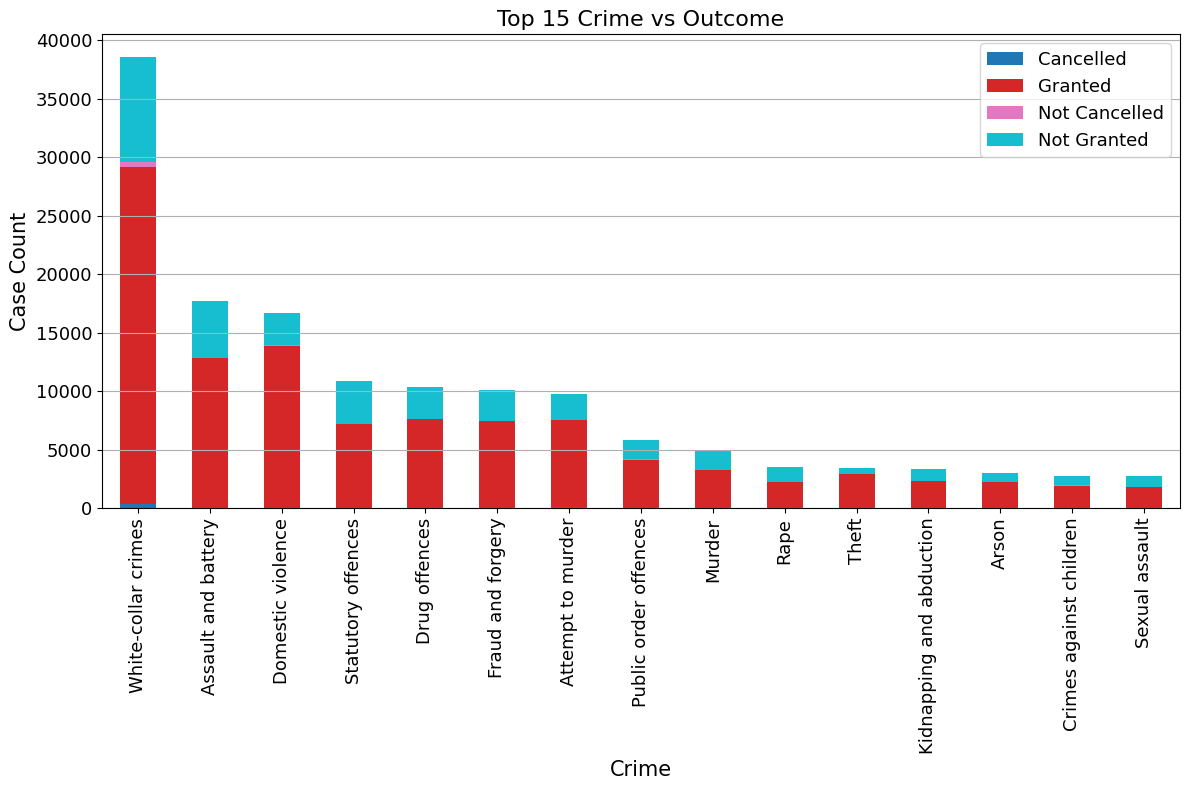

outcome,Cancelled,Granted,Not Cancelled,Not Granted
Crime,,,,
White-collar crimes,0.816252,74.675442,1.153119,23.355186
Assault and battery,0.084712,72.327328,0.248489,27.339470
Domestic violence,0.065797,82.892691,0.293097,16.748415
Statutory offences,0.257637,65.522635,0.460066,33.759661
Drug offences,0.260015,72.775424,0.269646,26.694915
Fraud and forgery,0.119237,74.046105,0.149046,25.685612
Attempt to murder,0.421984,76.636476,0.710169,22.231371
Public order offences,0.551059,70.742208,1.222662,27.484071
Murder,0.402414,65.211268,0.342052,34.044266


In [ ]:
from collections import Counter

# Explode and merge Crime with outcome
exploded_crime = df[['Crime', 'outcome']].explode('Crime').dropna()

# Get the top 15 crimes
crime_counts = exploded_crime['Crime'].value_counts().head(15).index

# Filter the exploded DataFrame to include only the top 15 crimes
top_crimes = exploded_crime[exploded_crime['Crime'].isin(crime_counts)]

# Create a crosstab of top crimes and outcome
top_crimes_ct = pd.crosstab(top_crimes['Crime'], top_crimes['outcome'])

# Order the crimes by total count in descending order
top_crimes_ct['Total'] = top_crimes_ct.sum(axis=1)
top_crimes_ct = top_crimes_ct.sort_values(by='Total', ascending=False).drop(columns='Total')


# Plot the stacked bar chart
ax = top_crimes_ct.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 8),
    colormap='tab10'
)
plt.grid(axis='y')

# Add percentage labels
# Calculate row (crime) totals for percent calculation
row_totals = top_crimes_ct.sum(axis=1).values

for i, container in enumerate(ax.containers):
    crime_names = top_crimes_ct.index.tolist()
    outcome_vals = top_crimes_ct.iloc[:, i].values
    labels = [
        f'{(val / row_totals[j] * 100):.1f}%' if val > 0 else ''
        for j, val in enumerate(outcome_vals)
    ]
    # ax.bar_label(container, labels=labels, label_type='center') # Commented out to remove labels

plt.title("Top 15 Crime vs Outcome",fontsize=16)
plt.ylabel("Case Count",fontsize=15)
plt.xlabel("Crime",fontsize=15)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(fontsize=13)
plt.tight_layout()
plt.show()

# Optional: probability (percentage split)
top_crimes_ratio = top_crimes_ct.div(top_crimes_ct.sum(axis=1), axis=0) * 100
display(top_crimes_ratio)

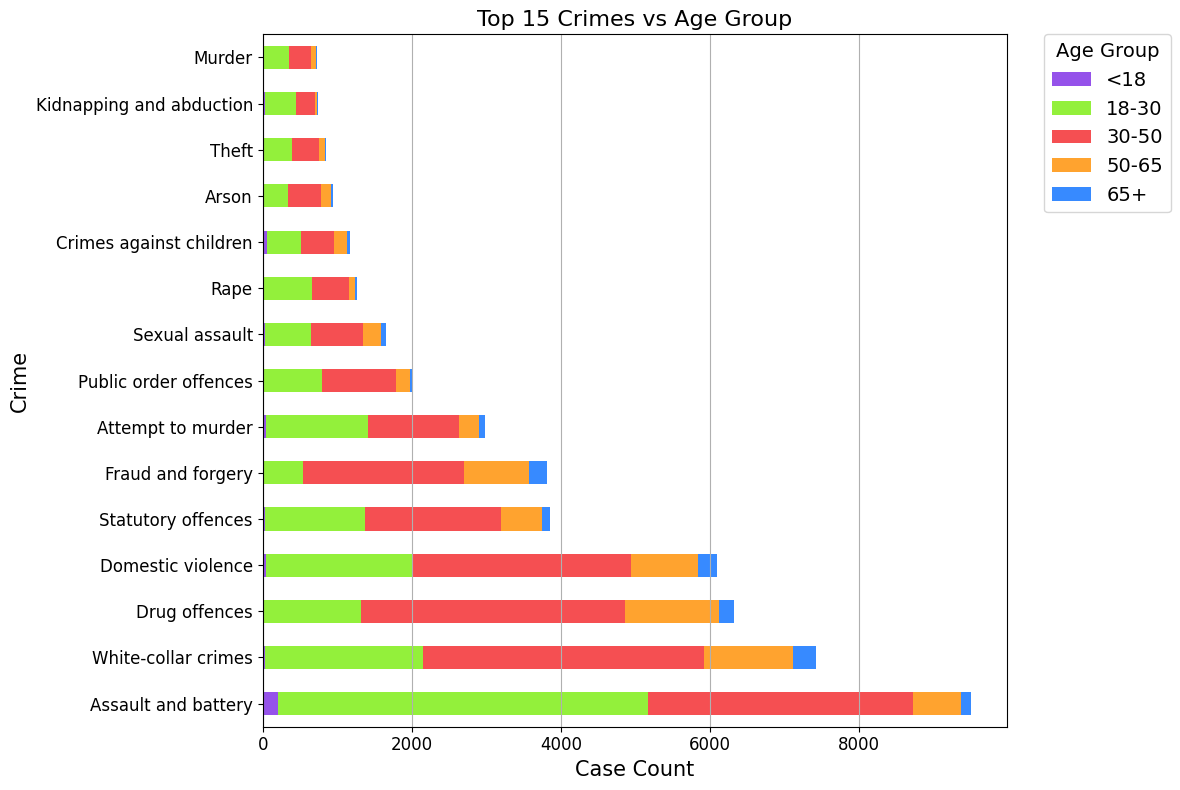

age_group,<18,18-30,30-50,50-65,65+
Crime,,,,,
Assault and battery,2.198149,52.156079,37.410602,6.741691,1.493479
White-collar crimes,0.444804,28.480927,50.882868,16.066855,4.124545
Drug offences,0.205534,20.600791,56.126482,19.794466,3.272727
Domestic violence,0.672021,32.404524,47.926569,14.718899,4.277987
Statutory offences,0.907206,34.577501,47.356143,14.256091,2.903059
Fraud and forgery,0.209644,14.124738,56.577568,22.851153,6.236897
Attempt to murder,1.543624,45.872483,40.973154,8.959732,2.651007
Public order offences,1.093983,38.388861,49.428145,9.249130,1.839881
Sexual assault,1.631420,37.341390,42.054381,15.105740,3.867069


In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Explode and merge Crime with age_group
exploded_crime = df[['Crime', 'age_group']].explode('Crime').dropna()

# Get the top 15 crimes
crime_counts = exploded_crime['Crime'].value_counts().head(15).index

# Filter the exploded DataFrame to include only the top 15 crimes
top_crimes = exploded_crime[exploded_crime['Crime'].isin(crime_counts)]

# Create a crosstab of top crimes and age_group
top_crimes_ct = pd.crosstab(top_crimes['Crime'], top_crimes['age_group'])

# Order the crimes by total count in descending order
top_crimes_ct['Total'] = top_crimes_ct.sum(axis=1)
top_crimes_ct = top_crimes_ct.sort_values(by='Total', ascending=False).drop(columns='Total')

# Remove brackets from crime names for better y-axis labels
top_crimes_ct.index = top_crimes_ct.index.str.replace('[', '').str.replace(']', '').str.replace("'", "")


# Plot the stacked bar chart
ax = top_crimes_ct.plot(
    kind='barh',
    stacked=True,
    figsize=(12, 8),
    # colormap='Set2' # Original colormap
    # color=['#ffa600','#C6D68F','#FBE29F','#E8A09A','#FF2E7E', '#64C2A6'] # Using the provided colors
    color=['#9552EA','#93F03B','#F54F52','#FFA32F','#378AFF','#FFEC21']
)
plt.grid(axis='x')


plt.title("Top 15 Crimes vs Age Group", fontsize=16) # Increased title font size
plt.ylabel("Crime", fontsize=15) # Increased ylabel font size
plt.xlabel("Case Count", fontsize=15) # Increased xlabel font size
plt.xticks(fontsize=12) # Increased xticks font size
plt.yticks(fontsize=12) # Increased yticks font size

# Add legend with increased font size and adjusted position/size
plt.legend(title='Age Group', fontsize=14, title_fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.) # Increased legend fontsize


plt.tight_layout()
plt.show()

# Optional: probability (percentage split)
top_crimes_ratio = top_crimes_ct.div(top_crimes_ct.sum(axis=1), axis=0) * 100
display(top_crimes_ratio)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150430 entries, 0 to 150429
Data columns (total 16 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   CNR                                150430 non-null  object        
 1   bail_type                          150430 non-null  object        
 2   is_withdrawal                      150430 non-null  object        
 3   age                                51517 non-null   float64       
 4   health_issues                      3686 non-null    object        
 5   past_criminal_record               150430 non-null  object        
 6   statutes                           150430 non-null  object        
 7   outcome                            150430 non-null  object        
 8   date_of_arrest                     43012 non-null   datetime64[ns]
 9   date_of_judgement                  147311 non-null  datetime64[ns]
 10  case_details_length 

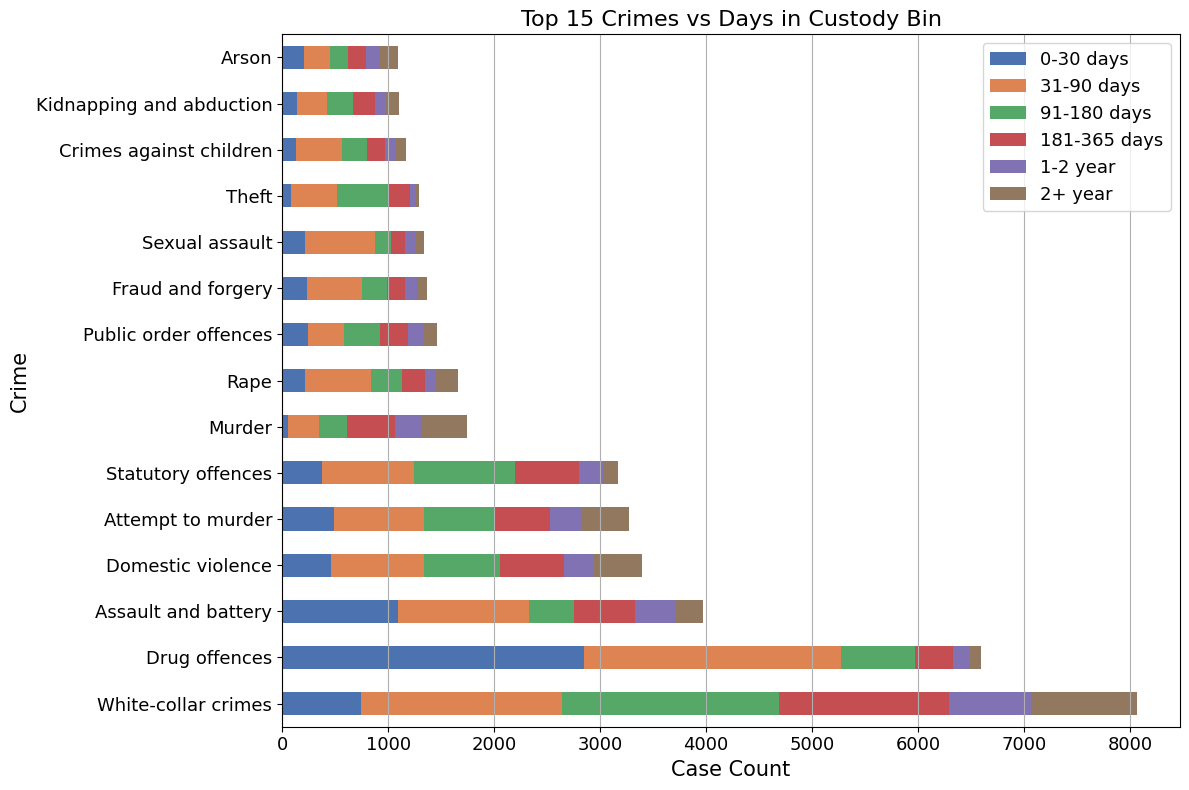

days_bin,0-30 days,31-90 days,91-180 days,181-365 days,1-2 year,2+ year
Crime,,,,,,
White-collar crimes,9.187849,23.521389,25.368878,19.913205,9.671420,12.337260
Drug offences,43.123578,36.876422,10.568613,5.352540,2.426080,1.652767
Assault and battery,27.483611,31.265759,10.690872,14.397378,9.531014,6.631367
Domestic violence,13.590802,26.002358,20.990566,17.895047,8.313679,13.207547
Attempt to murder,15.027489,25.962126,19.945021,16.188149,9.163103,13.714111
Statutory offences,11.809283,27.376066,30.154721,19.040101,7.136091,4.483739
Murder,3.390805,16.666667,15.287356,25.689655,14.482759,24.482759
Rape,13.027744,37.696019,17.310012,13.329312,6.212304,12.424608
Public order offences,16.484268,23.597811,22.913817,18.125855,9.575923,9.302326


In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Explode and merge Crime with days_bin
exploded_crime = df[['Crime', 'days_bin']].explode('Crime').dropna()

# Get the top 15 crimes
crime_counts = exploded_crime['Crime'].value_counts().head(15).index

# Filter the exploded DataFrame to include only the top 15 crimes
top_crimes = exploded_crime[exploded_crime['Crime'].isin(crime_counts)]

# Create a crosstab of top crimes and days_bin
top_crimes_ct = pd.crosstab(top_crimes['Crime'], top_crimes['days_bin'])

# Order the crimes by total count in descending order
top_crimes_ct['Total'] = top_crimes_ct.sum(axis=1)
top_crimes_ct = top_crimes_ct.sort_values(by='Total', ascending=False).drop(columns='Total')

palette = sns.color_palette("deep", n_colors=len(top_crimes_ct.columns))
# Plot the stacked bar chart
ax = top_crimes_ct.plot(
    kind='barh',
    stacked=True,
    figsize=(12, 8),
    color=palette
)
plt.grid(axis='x')

plt.title("Top 15 Crimes vs Days in Custody Bin",fontsize=16)
plt.ylabel("Crime",fontsize=15)
plt.xlabel("Case Count",fontsize=15)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(fontsize=13)
plt.tight_layout()
plt.show()

# Optional: probability (percentage split)
top_crimes_ratio = top_crimes_ct.div(top_crimes_ct.sum(axis=1), axis=0) * 100
display(top_crimes_ratio)

# SECTION 3: Multivariate Analysis

#### 3.1 Bail Type vs Age Group vs Outcome (Stacked Bar)

/tmp/ipython-input-86-1766302523.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = combo.pivot_table(index=['bail_type', 'age_group'],


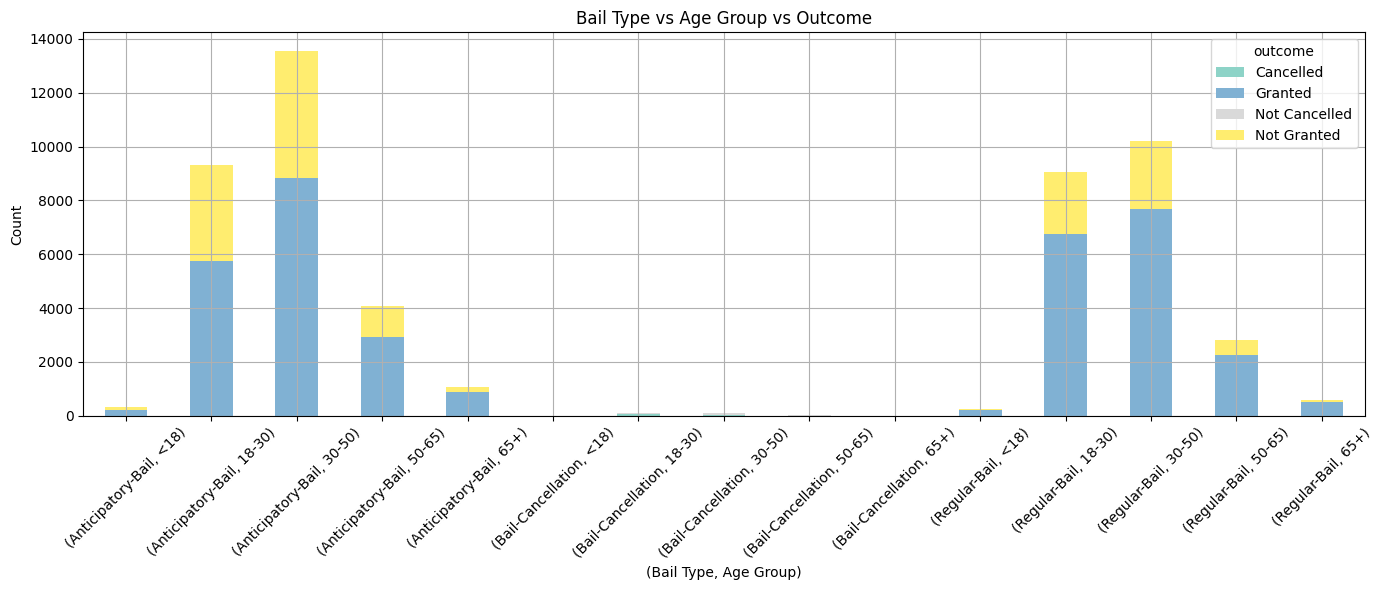

In [ ]:
# Prepare data
combo = df[['bail_type', 'age_group', 'outcome']].dropna()
pivot_table = combo.pivot_table(index=['bail_type', 'age_group'],
                                columns='outcome',
                                aggfunc=len,
                                fill_value=0)

# Plot
pivot_table.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='Set3')
plt.title('Bail Type vs Age Group vs Outcome')
plt.xlabel('(Bail Type, Age Group)')
plt.ylabel('Count')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### 3.2 Bail Type vs Past Criminal Record vs Outcome

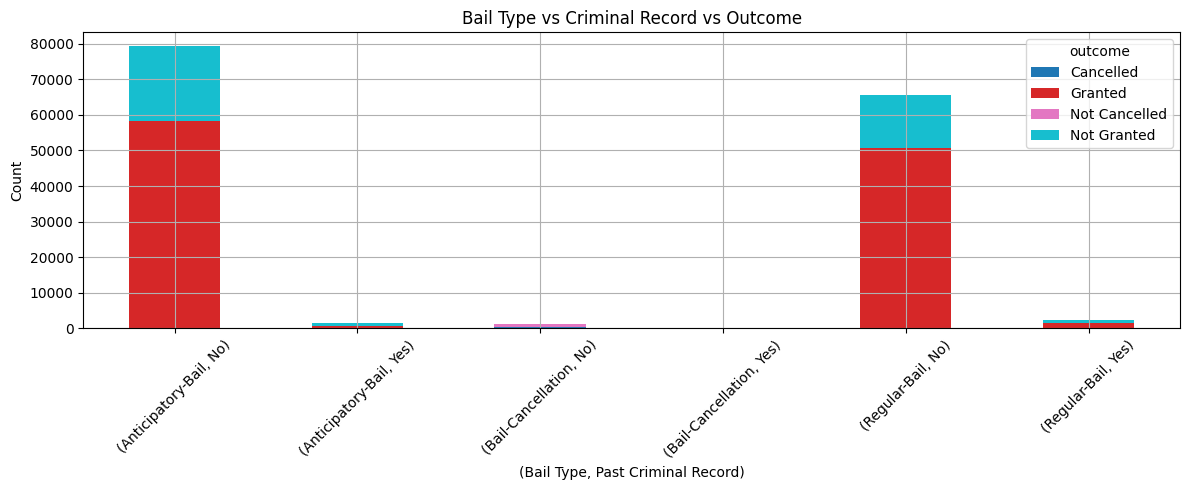

In [ ]:
combo2 = df[['bail_type', 'past_criminal_record', 'outcome']].dropna()
pivot_table2 = combo2.pivot_table(index=['bail_type', 'past_criminal_record'],
                                  columns='outcome',
                                  aggfunc=len,
                                  fill_value=0)

pivot_table2.plot(kind='bar', stacked=True, figsize=(12, 5), colormap='tab10')
plt.title('Bail Type vs Criminal Record vs Outcome')
plt.xlabel('(Bail Type, Past Criminal Record)')
plt.ylabel('Count')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### 3.3 Bail Type vs Number of Statutes vs Outcome (Violin Plot)

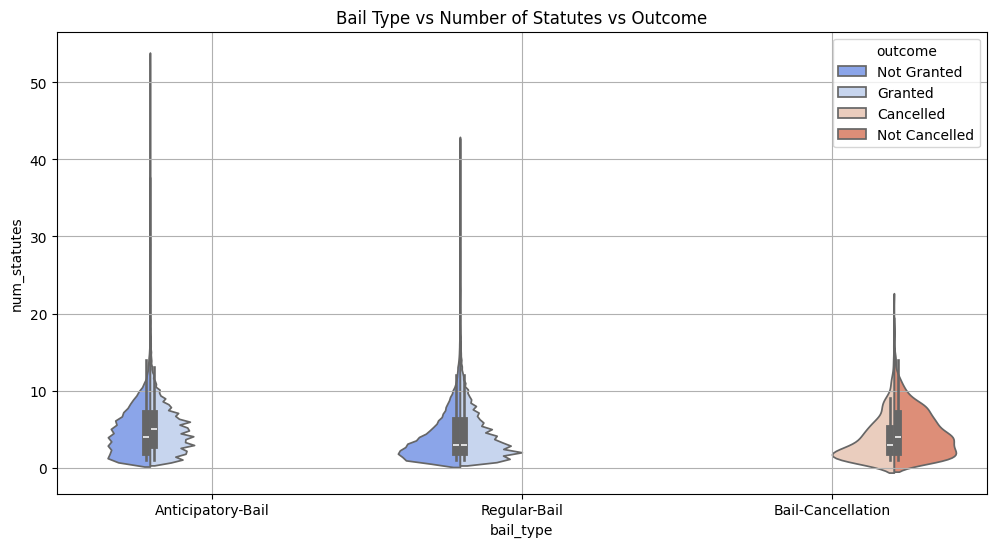

In [ ]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='bail_type', y='num_statutes', hue='outcome',
               split=True, palette='coolwarm')
plt.title('Bail Type vs Number of Statutes vs Outcome')
plt.grid(True)
plt.show()


#### 3.4 Correlation Heatmap (Numerical Only)



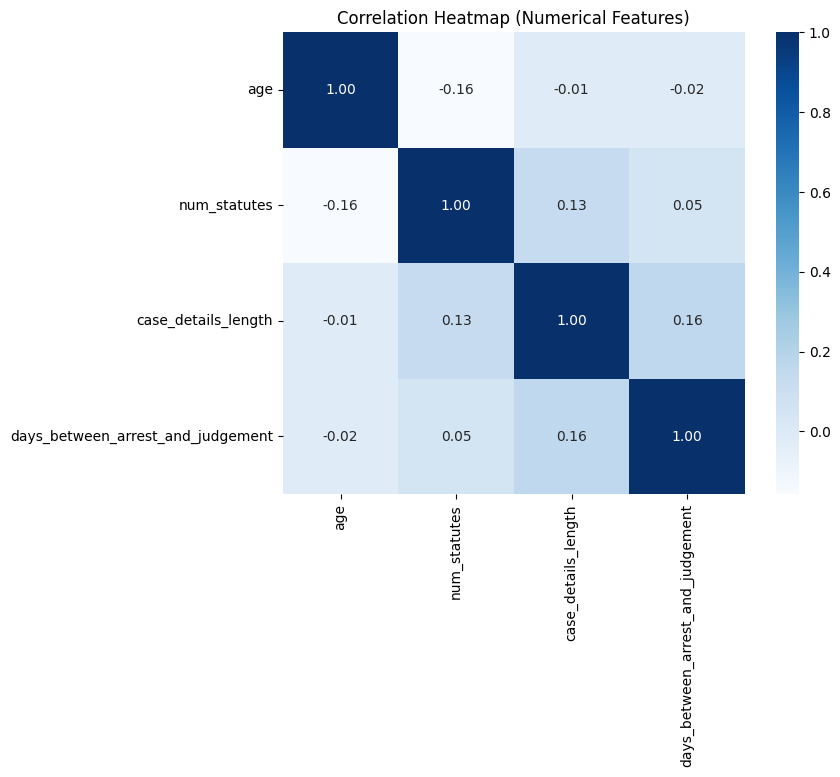

In [ ]:
# Select numeric columns
numeric_cols = ['age', 'num_statutes', 'case_details_length', 'days_between_arrest_and_judgement']
corr = df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f", square=True)
plt.title('Correlation Heatmap (Numerical Features)')
plt.show()


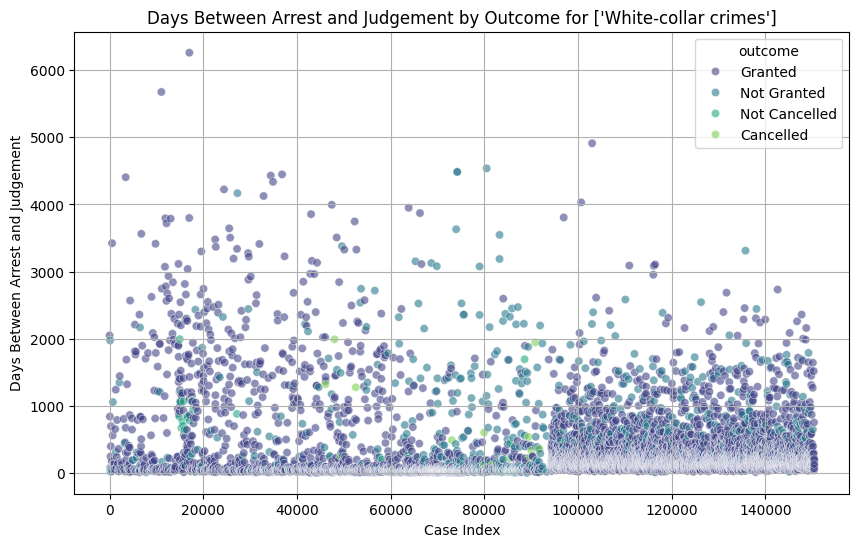

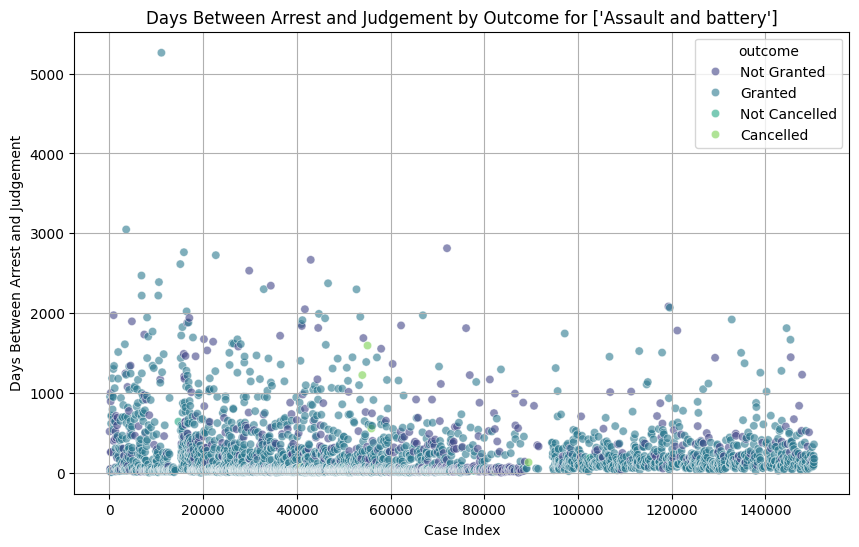

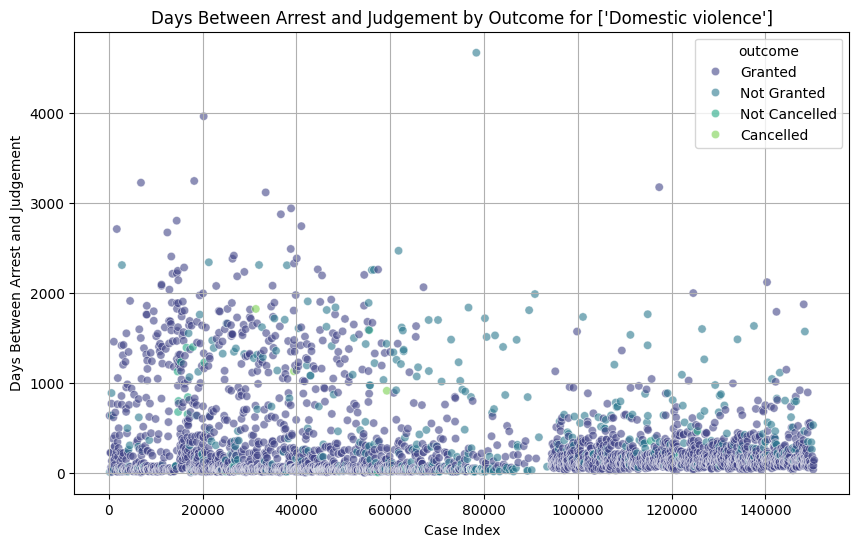

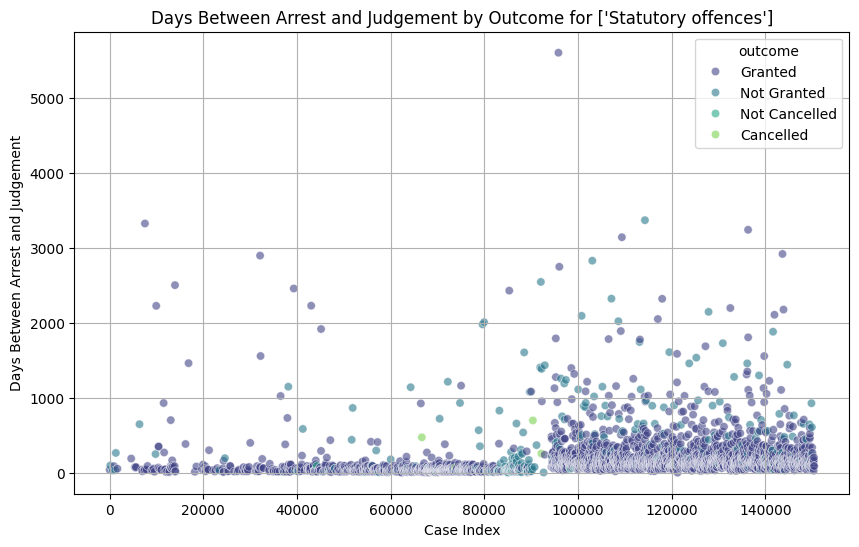

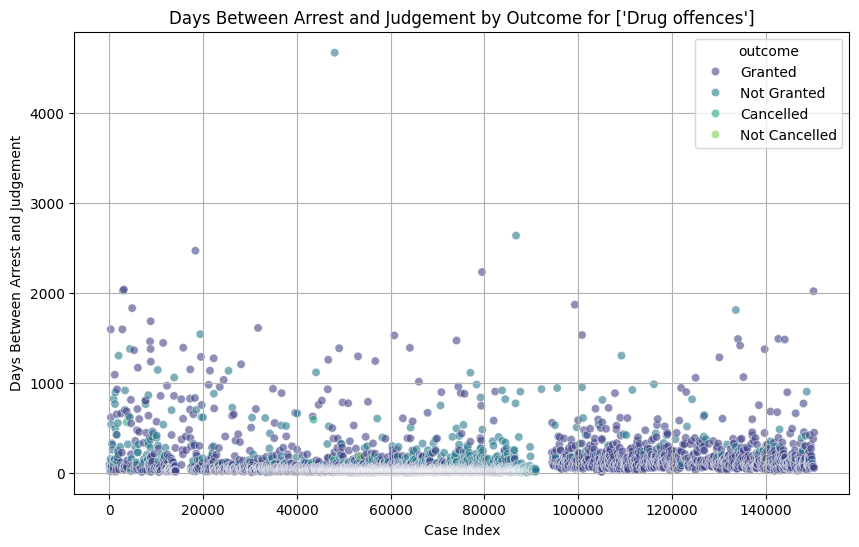

#### 3D Scatter — Custody, Age, Case Length Colored by Outcome

In [ ]:
import plotly.express as px

fig = px.scatter_3d(
    df[df['days_between_arrest_and_judgement'].notna()],
    x='age', y='case_details_length', z='days_between_arrest_and_judgement',
    color='outcome',
    title='Age vs Case Length vs Custody Duration (by Outcome)',
    labels={'days_between_arrest_and_judgement': 'Custody Duration'},
    height=600
)
fig.show()

,CNR,bail_type,is_withdrawal,age,health_issues,past_criminal_record,statutes,outcome,date_of_arrest,date_of_judgement,case_details_length,Crime,age_group,num_statutes,days_between_arrest_and_judgement
101774,JHHC010047062017,Regular-Bail,No,NaN,NaN,No,"[Section 392 IPC, Section 411 IPC]",Granted,2016-10-04,2017-03-03,114,['Theft'],NaN,2,150.0
